In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Environment check successful!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("yfinance:", yf.__version__)

Environment check successful!
Pandas: 3.0.5
NumPy: 2.5.2
Matplotlib: 3.11.1
yfinance: 1.5.2


# Apple Inc. (AAPL) Historical Stock Analysis

## Data Source

Historical AAPL market data sourced from Yahoo Finance.

Source:
https://finance.yahoo.com/quote/AAPL/history/

Data retrieval:
Python `yfinance` library

The dataset contains historical market observations for Apple Inc. (AAPL).

In [101]:
aapl_raw = yf.download(
    "AAPL",
    period="max",
    auto_adjust=False
)

aapl_raw.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
1980-12-12,0.098122,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093003,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086177,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088310,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.090870,0.118862,0.119420,0.118862,0.118862,73449600


In [102]:
aapl_raw.to_csv("../data_raw/AAPL_historical_raw.csv")

## 1. Business Understanding

### Analytical Context

This project analyzes historical market data for Apple Inc. (AAPL) using historical observations sourced from Yahoo Finance.

The dataset contains daily market observations including opening price, highest price, lowest price, closing price, adjusted closing price, and trading volume.

### Preliminary Analytical Grain

Based on the initial data retrieval, each observation represents one trading-day record for AAPL.

### Analytical Objective

The objective is to investigate historical price behavior, trading activity, returns, volatility, trends, and other meaningful patterns that can be derived from the available market data.

### Potential Analytical Questions

The analysis will investigate questions such as:

- How has AAPL's price changed over time?
- What periods experienced unusually high or low returns?
- How has price volatility changed over time?
- How does trading volume behave during periods of significant price movement?
- Are there identifiable trends or recurring patterns in the historical series?
- What additional features can be derived to support meaningful time-series analysis?

### Scope and Limitations

This dataset contains historical market observations. Therefore, the analysis can describe historical price and trading behavior but should not automatically be interpreted as evidence of future stock performance or causation.

Further conclusions will depend on the results of the data-quality investigation and exploratory analysis.

In [103]:
import pandas as pd

raw_path = "../data_raw/AAPL_historical_raw.csv"

raw_check = pd.read_csv(raw_path)

print("Shape:", raw_check.shape)
print("\nFirst 5 rows:")
display(raw_check.head())

Shape: (11508, 7)

First 5 rows:


,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,1980-12-12,0.09812237322330475,0.1283479928970337,0.1289059966802597,0.1283479928970337,0.1283479928970337,469033600
3,1980-12-15,0.0930032804608345,0.12165199965238571,0.12221000343561172,0.12165199965238571,0.12221000343561172,175884800
4,1980-12-16,0.0861770287156105,0.11272300034761429,0.1132809966802597,0.11272300034761429,0.1132809966802597,105728000


In [104]:
raw_structure = pd.read_csv(
    raw_path,
    header=None,
    nrows=6
)

display(raw_structure)

,0,1,2,3,4,5,6
0,Price,Adj Close,Close,High,Low,Open,Volume
1,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
2,Date,NaN,NaN,NaN,NaN,NaN,NaN
3,1980-12-12,0.09812237322330475,0.1283479928970337,0.1289059966802597,0.1283479928970337,0.1283479928970337,469033600
4,1980-12-15,0.0930032804608345,0.12165199965238571,0.12221000343561172,0.12165199965238571,0.12221000343561172,175884800
5,1980-12-16,0.0861770287156105,0.11272300034761429,0.1132809966802597,0.11272300034761429,0.1132809966802597,105728000


In [105]:
aapl = pd.read_csv(
    raw_path,
    skiprows=[1, 2]
)

# Rename the first column from "Price" to "Date"
aapl = aapl.rename(columns={"Price": "Date"})

# Convert Date to datetime
aapl["Date"] = pd.to_datetime(aapl["Date"])

display(aapl.head())

,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098122,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093003,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086177,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088310,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.090870,0.118862,0.119420,0.118862,0.118862,73449600


In [106]:
print("Shape:", aapl.shape)

print("\nColumns:")
print(aapl.columns.tolist())

print("\nData types:")
print(aapl.dtypes)

print("\nDate range:")
print("Start:", aapl["Date"].min())
print("End:", aapl["Date"].max())

Shape: (11506, 7)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Date         datetime64[us]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Date range:
Start: 1980-12-12 00:00:00
End: 2026-08-10 00:00:00


### 2.1 Missing Values and Duplicate Records

This check evaluates whether the analytical dataset contains missing observations, duplicated records, or repeated trading dates.

The analytical grain is currently defined as one observation per AAPL trading date.

The results of this check will determine whether missing-value treatment or duplicate-record investigation is required before further analysis.

In [107]:
print("Missing values by column:")
print(aapl.isna().sum())

print("\nDuplicate rows:")
print(aapl.duplicated().sum())

print("\nDuplicate dates:")
print(aapl["Date"].duplicated().sum())

print("\nUnique dates:")
print(aapl["Date"].nunique())

print("\nTotal rows:")
print(len(aapl))

Missing values by column:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate rows:
0

Duplicate dates:
0

Unique dates:
11506

Total rows:
11506


### 2.2 Internal Consistency of OHLC Prices

The Open, High, Low, and Close fields should satisfy basic internal relationships for each trading-day observation.

The analysis will test whether:

- High is greater than or equal to Low
- High is greater than or equal to Open
- High is greater than or equal to Close
- Low is less than or equal to Open
- Low is less than or equal to Close
- Prices are positive

These checks are used to identify potentially invalid records rather than to remove observations automatically.

In [108]:
ohlc_issues = {
    "High < Low": (aapl["High"] < aapl["Low"]).sum(),
    "High < Open": (aapl["High"] < aapl["Open"]).sum(),
    "High < Close": (aapl["High"] < aapl["Close"]).sum(),
    "Low > Open": (aapl["Low"] > aapl["Open"]).sum(),
    "Low > Close": (aapl["Low"] > aapl["Close"]).sum(),
    "Non-positive Open": (aapl["Open"] <= 0).sum(),
    "Non-positive High": (aapl["High"] <= 0).sum(),
    "Non-positive Low": (aapl["Low"] <= 0).sum(),
    "Non-positive Close": (aapl["Close"] <= 0).sum(),
}

for check, count in ohlc_issues.items():
    print(f"{check}: {count}")

High < Low: 0
High < Open: 0
High < Close: 0
Low > Open: 0
Low > Close: 0
Non-positive Open: 0
Non-positive High: 0
Non-positive Low: 0
Non-positive Close: 0


### 2.3 Chronological Integrity

Because this is a time-series dataset, observations must be correctly ordered by trading date before calculating returns, rolling statistics, volatility, or other time-dependent features.

This check will determine whether the Date field is monotonically increasing and whether any unexpected date reversals exist.

In [109]:
print("Dates in chronological order:", aapl["Date"].is_monotonic_increasing)

print("\nNumber of date reversals:")
print((aapl["Date"].diff().dt.total_seconds() < 0).sum())

print("\nFirst 5 dates:")
print(aapl["Date"].head().to_list())

print("\nLast 5 dates:")
print(aapl["Date"].tail().to_list())

Dates in chronological order: True

Number of date reversals:
0

First 5 dates:
[Timestamp('1980-12-12 00:00:00'), Timestamp('1980-12-15 00:00:00'), Timestamp('1980-12-16 00:00:00'), Timestamp('1980-12-17 00:00:00'), Timestamp('1980-12-18 00:00:00')]

Last 5 dates:
[Timestamp('2026-08-04 00:00:00'), Timestamp('2026-08-05 00:00:00'), Timestamp('2026-08-06 00:00:00'), Timestamp('2026-08-07 00:00:00'), Timestamp('2026-08-10 00:00:00')]


### 2.4 Trading Volume Validation

Trading volume represents the number of shares traded during each market observation.

The volume field will be checked for zero or negative values and examined for unusually large observations.

A non-zero or extreme value will not automatically be treated as an error. Financial market volume can vary substantially across trading periods, so any unusual observations must be investigated in context before treatment.

In [110]:
print("Zero-volume observations:", (aapl["Volume"] == 0).sum())
print("Negative-volume observations:", (aapl["Volume"] < 0).sum())

print("\nVolume summary:")
print(aapl["Volume"].describe())

print("\nFive highest-volume observations:")
display(
    aapl.nlargest(5, "Volume")[["Date", "Volume"]]
)

Zero-volume observations: 1
Negative-volume observations: 0

Volume summary:
count    1.150600e+04
mean     3.063385e+08
std      3.325258e+08
min      0.000000e+00
25%      1.039855e+08
50%      1.953748e+08
75%      3.862313e+08
max      7.421641e+09
Name: Volume, dtype: float64

Five highest-volume observations:


,Date,Volume
5004,2000-09-29,7421640800
4209,1997-08-06,4190480000
4210,1997-08-07,3755438400
6840,2008-01-23,3372969600
4744,1999-09-21,3357558400


### 2.5 Investigation of Zero-Volume Observation

The volume validation identified one observation with zero reported trading volume.

Because the dataset represents daily market observations, this record requires investigation before deciding whether it represents a genuine market-data condition, a source-data issue, or an observation that should be excluded.

The record will be examined alongside its date and corresponding OHLC price fields.

No treatment will be applied until the observation has been investigated.

In [111]:
zero_volume = aapl[aapl["Volume"] == 0]

display(zero_volume)

,Date,Adj Close,Close,High,Low,Open,Volume
165,1981-08-10,0.086177,0.112723,0.112723,0.112723,0.112723,0


### 2.5.1 Contextual Investigation

The zero-volume observation will be compared with nearby trading-day records to determine whether the issue is isolated or part of a broader pattern.

The surrounding observations will be examined for changes in:

- Trading volume
- Open, High, Low, and Close prices
- Date continuity
- Price movement

The purpose is to distinguish a potential source-data anomaly from a legitimate historical observation.

In [112]:
zero_date = zero_volume["Date"].iloc[0]

context = aapl[
    (aapl["Date"] >= zero_date - pd.Timedelta(days=5)) &
    (aapl["Date"] <= zero_date + pd.Timedelta(days=5))
][["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]

display(context)

,Date,Open,High,Low,Close,Adj Close,Volume
162,1981-08-05,0.115513,0.116071,0.115513,0.115513,0.088310,17494400
163,1981-08-06,0.113281,0.113281,0.112723,0.112723,0.086177,10528000
164,1981-08-07,0.112723,0.113281,0.112723,0.112723,0.086177,9206400
165,1981-08-10,0.112723,0.112723,0.112723,0.112723,0.086177,0
166,1981-08-11,0.110491,0.110491,0.109375,0.109375,0.083618,71456000
167,1981-08-12,0.107701,0.107701,0.107143,0.107143,0.081911,26275200
168,1981-08-13,0.104353,0.104353,0.103795,0.103795,0.079352,27484800
169,1981-08-14,0.103237,0.103237,0.102121,0.102121,0.078072,24192000


### 2.5.2 Treatment Decision

The contextual investigation shows that the zero-volume observation on 1981-08-10 is isolated, with non-zero trading volume immediately before and after the date.

The OHLC values for the observation are internally consistent and the date falls correctly within the chronological series.

Because there is insufficient evidence to determine the true trading volume for this date, the volume value will not be imputed or manually replaced.

The observation will therefore be retained in the analytical dataset and flagged as a zero-volume record.

This preserves the source data while allowing volume-based analyses to identify and appropriately handle the observation when necessary.

### 2.6 Volume Distribution and Extreme Observations

The volume distribution contains highly unusual historical observations relative to the median.

Extreme values will be investigated using both distributional statistics and their position in the historical series.

The purpose is to determine whether the observations represent potential data-quality issues or legitimate historical market activity.

Extreme values will not be removed solely because they are statistically unusual.

In [113]:
# Calculate key volume percentiles
volume_percentiles = aapl["Volume"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

print("Volume percentiles:")
display(volume_percentiles)

# Identify observations above the 99th percentile
volume_99 = aapl[aapl["Volume"] > volume_percentiles.loc[0.99]]

print("\nNumber of observations above the 99th percentile:",
      len(volume_99))

print("\nHighest-volume observations above the 99th percentile:")
display(
    volume_99.nlargest(10, "Volume")[
        ["Date", "Open", "High", "Low", "Close", "Volume"]
    ]
)

Volume percentiles:


0.500    1.953748e+08
0.750    3.862313e+08
0.900    6.979322e+08
0.950    9.415567e+08
0.990    1.637948e+09
0.999    2.680459e+09
Name: Volume, dtype: float64


Number of observations above the 99th percentile: 116

Highest-volume observations above the 99th percentile:


,Date,Open,High,Low,Close,Volume
5004,2000-09-29,0.503348,0.517857,0.453125,0.459821,7421640800
4209,1997-08-06,0.225446,0.247768,0.223214,0.234933,4190480000
4210,1997-08-07,0.256696,0.263951,0.253348,0.260603,3755438400
6840,2008-01-23,4.863929,5.000000,4.505000,4.966786,3372969600
4744,1999-09-21,0.653460,0.654018,0.616071,0.618304,3357558400
6579,2007-01-09,3.087500,3.320714,3.041071,3.306071,3349298400
6080,2005-01-13,1.316250,1.328929,1.245179,1.246429,3164716800
6580,2007-01-10,3.383929,3.492857,3.337500,3.464286,2952880000
703,1983-09-23,0.111607,0.111607,0.099330,0.108259,2832345600
6017,2004-10-14,0.771250,0.816964,0.759821,0.803214,2768427200


### 2.6.1 Corporate-Action Context

Extreme historical trading-volume observations will be investigated alongside AAPL corporate-action data.

Stock splits can affect the representation of historical market prices and trading volume in financial datasets. Therefore, extreme historical volume should not be classified as erroneous without considering the underlying corporate-action history.

The purpose of this check is to determine whether corporate actions provide relevant context for the unusually high historical volume observations.

No volume values will be altered based on this investigation alone.

In [114]:
import yfinance as yf

aapl_ticker = yf.Ticker("AAPL")

actions = aapl_ticker.actions

display(actions.head())

,Dividends,Stock Splits
Date,,
1987-05-11 00:00:00-04:00,0.000536,0.0
1987-06-16 00:00:00-04:00,0.000000,2.0
1987-08-10 00:00:00-04:00,0.000536,0.0
1987-11-17 00:00:00-05:00,0.000714,0.0
1988-02-12 00:00:00-05:00,0.000714,0.0


### 2.6.2 Stock-Split History

The complete AAPL stock-split history will be examined to determine whether unusually high historical trading-volume observations occur around periods affected by stock splits.

The split history will be compared with the dates of extreme-volume observations.

This comparison is exploratory and will not be used by itself to classify observations as erroneous.

In [115]:
stock_splits = actions[actions["Stock Splits"] > 0][["Stock Splits"]]

print("AAPL stock splits:")
display(stock_splits)

AAPL stock splits:


,Stock Splits
Date,
1987-06-16 00:00:00-04:00,2.0
2000-06-21 00:00:00-04:00,2.0
2005-02-28 00:00:00-05:00,2.0
2014-06-09 00:00:00-04:00,7.0
2020-08-31 00:00:00-04:00,4.0


### 2.6.3 Comparing Extreme Volume With Stock Splits

The dates of the highest-volume observations will be compared with AAPL's historical stock-split dates.

This comparison will determine whether the extreme-volume observations occur immediately before, on, or after stock-split dates.

The purpose is contextual investigation only. Extreme volume will not be classified as erroneous solely because it occurs near a corporate action.

In [116]:
# Get the 10 highest-volume observations
top_volume = aapl.nlargest(
    10,
    "Volume"
)[["Date", "Volume"]].copy()

# Convert split dates to timezone-naive dates for comparison
split_dates = stock_splits.index.tz_localize(None)

# Calculate the number of calendar days from each high-volume date
# to the nearest stock-split date
top_volume["Days_to_nearest_split"] = top_volume["Date"].apply(
    lambda x: min(abs((x - split_date).days) for split_date in split_dates)
)

display(top_volume)

,Date,Volume,Days_to_nearest_split
5004,2000-09-29,7421640800,100
4209,1997-08-06,4190480000,1050
4210,1997-08-07,3755438400,1049
6840,2008-01-23,3372969600,1059
4744,1999-09-21,3357558400,274
6579,2007-01-09,3349298400,680
6080,2005-01-13,3164716800,46
6580,2007-01-10,2952880000,681
703,1983-09-23,2832345600,1362
6017,2004-10-14,2768427200,137


### 2.6.4 Volume Anomaly Treatment Decision

The volume distribution is strongly right-skewed, with a small number of observations exhibiting exceptionally high trading volume.

The 99th percentile is approximately 1.64 billion shares, while the maximum is approximately 7.42 billion shares.

The highest-volume observations were compared with AAPL's historical stock-split dates. Most of the extreme observations are substantially separated from the nearest stock-split date, so stock splits alone do not provide sufficient evidence to classify these observations as erroneous.

Because extreme trading volume can represent legitimate historical market activity, the observations will be retained.

No statistical outlier-removal rule will be applied to the Volume field.

The previously identified zero-volume observation will remain in the dataset and will be flagged separately.

### 2.7 Data-Quality Flag

A quality flag will be created to identify observations with zero reported trading volume.

The original Volume value will remain unchanged.

This flag allows later volume-based analysis to distinguish the unusual observation without altering the source measurement.

In [117]:
aapl["Zero_Volume_Flag"] = aapl["Volume"].eq(0)

print("Zero-volume flags:")
print(aapl["Zero_Volume_Flag"].value_counts())

Zero-volume flags:
Zero_Volume_Flag
False    11505
True         1
Name: count, dtype: int64


### 2.8 Final Data-Quality Validation

The analytical dataframe will undergo a final structural validation after the quality flag has been added.

The validation confirms that:

- The original number of observations has been preserved.
- The expected columns are present.
- No new missing values were introduced.
- Trading dates remain unique.
- The zero-volume quality flag contains the expected number of flagged observations.

Only after these checks pass will the analytical dataframe be saved as the cleaned-data layer.

In [118]:
print("Shape:", aapl.shape)

print("\nMissing values:")
print(aapl.isna().sum())

print("\nDuplicate dates:", aapl["Date"].duplicated().sum())

print("\nZero-volume flags:")
print(aapl["Zero_Volume_Flag"].value_counts())

print("\nData types:")
print(aapl.dtypes)

Shape: (11506, 8)

Missing values:
Date                0
Adj Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
Zero_Volume_Flag    0
dtype: int64

Duplicate dates: 0

Zero-volume flags:
Zero_Volume_Flag
False    11505
True         1
Name: count, dtype: int64

Data types:
Date                datetime64[us]
Adj Close                  float64
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
Zero_Volume_Flag              bool
dtype: object


## 3. Cleaned Analytical Dataset

The data-quality assessment has been completed and the analytical dataframe has been validated.

The cleaned dataset preserves all 11,506 original observations and retains the original market variables without imputation or removal of observations.

A `Zero_Volume_Flag` field has been added to identify the single zero-volume observation without modifying the original Volume value.

The cleaned analytical dataset will be saved separately from the raw source data to maintain reproducibility and data lineage.

### 3.1 Export Cleaned Dataset

The validated analytical dataframe will be exported to the `02_Cleaned_Data` directory for use in subsequent time-series analysis and feature engineering.

In [119]:
from pathlib import Path

cleaned_path = Path("../02_Cleaned_Data/AAPL_historical_cleaned.csv")

aapl.to_csv(cleaned_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_path}")

Cleaned dataset saved to: ..\02_Cleaned_Data\AAPL_historical_cleaned.csv


## 4. Feature Engineering

### Objective

The cleaned dataset provides validated daily AAPL market observations.
The next stage is to derive analytical variables that capture price movement,
market activity, volatility and longer-term trends.

Feature engineering will be performed only where the derived variable has a
clear analytical or business purpose.

### Principles

- Preserve the original market variables.
- Avoid modifying historical observations unnecessarily.
- Ensure time-series features do not introduce look-ahead bias.
- Validate derived variables against the underlying data.
- Keep the cleaned dataset separate from analytical transformations.

In [120]:
# Create a separate analytical dataframe
aapl_analysis = aapl.copy()

print("Analytical dataframe created.")
print("Shape:", aapl_analysis.shape)

Analytical dataframe created.
Shape: (11506, 8)


In [121]:
# Calculate daily adjusted-price return
aapl_analysis["Daily_Return"] = aapl_analysis["Adj Close"].pct_change()

print(aapl_analysis[["Date", "Adj Close", "Daily_Return"]].head())

        Date  Adj Close  Daily_Return
0 1980-12-12   0.098122           NaN
1 1980-12-15   0.093003     -0.052170
2 1980-12-16   0.086177     -0.073398
3 1980-12-17   0.088310      0.024751
4 1980-12-18   0.090870      0.028993


### 5.1 Daily Return

Daily return measures the percentage change in Apple's adjusted closing price
from one trading day to the next.

The calculation uses `Adj Close` rather than `Close` because adjusted prices
account for historical corporate actions such as stock splits and dividends.

Formula:

Daily Return = (Current Adj Close - Previous Adj Close) / Previous Adj Close

The first observation has no daily return because there is no preceding
trading-day observation.

#### Validation

The calculated return was independently compared with a manually calculated
return for the second observation. The values matched to floating-point
precision, confirming that the `pct_change()` calculation is functioning as
expected.

In [183]:
# Manually validate the second observation
previous_price = aapl_analysis.loc[0, "Adj Close"]
current_price = aapl_analysis.loc[1, "Adj Close"]

manual_return = (current_price - previous_price) / previous_price
calculated_return = aapl_analysis.loc[1, "Daily_Return"]

print("Previous adjusted close:", previous_price)
print("Current adjusted close:", current_price)
print("Manual return:", manual_return)
print("Pandas return:", calculated_return)
print(
    "Values match within floating-point tolerance:",
    np.isclose(manual_return, calculated_return)
)

Previous adjusted close: 0.0981223732233047
Current adjusted close: 0.0930032804608345
Manual return: -0.05217049480468931
Pandas return: -0.05217049480468927
Values match within floating-point tolerance: True


### 5.2 Intraday Price Range

The intraday price range measures the difference between Apple's highest and
lowest observed price during a trading day.

Two measures are created:

- `Intraday_Range`: absolute difference between the daily High and Low prices.
- `Intraday_Range_Pct`: intraday range expressed as a percentage of the
  opening price.

Formula:

Intraday Range = High - Low

Intraday Range % = (High - Low) / Open

The absolute range captures the magnitude of the daily price movement, while
the percentage range allows comparison across different price levels and
different periods in Apple's history.

In [123]:
# Calculate intraday price range
aapl_analysis["Intraday_Range"] = (
    aapl_analysis["High"] - aapl_analysis["Low"]
)

# Calculate intraday range as a percentage of the opening price
aapl_analysis["Intraday_Range_Pct"] = (
    aapl_analysis["Intraday_Range"] / aapl_analysis["Open"]
)

print(
    aapl_analysis[
        [
            "Date",
            "Open",
            "High",
            "Low",
            "Intraday_Range",
            "Intraday_Range_Pct"
        ]
    ].head()
)

        Date      Open      High       Low  Intraday_Range  Intraday_Range_Pct
0 1980-12-12  0.128348  0.128906  0.128348        0.000558            0.004348
1 1980-12-15  0.122210  0.122210  0.121652        0.000558            0.004566
2 1980-12-16  0.113281  0.113281  0.112723        0.000558            0.004926
3 1980-12-17  0.115513  0.116071  0.115513        0.000558            0.004831
4 1980-12-18  0.118862  0.119420  0.118862        0.000558            0.004694


In [124]:
# Validate the first observation manually
high = aapl_analysis.loc[0, "High"]
low = aapl_analysis.loc[0, "Low"]
open_price = aapl_analysis.loc[0, "Open"]

manual_range = high - low
manual_range_pct = manual_range / open_price

calculated_range = aapl_analysis.loc[0, "Intraday_Range"]
calculated_range_pct = aapl_analysis.loc[0, "Intraday_Range_Pct"]

print("Manual intraday range:", manual_range)
print("Calculated intraday range:", calculated_range)

print("\nManual intraday range %:", manual_range_pct)
print("Calculated intraday range %:", calculated_range_pct)

print("\nRange matches:",
      abs(manual_range - calculated_range) < 1e-12)

print("Range % matches:",
      abs(manual_range_pct - calculated_range_pct) < 1e-12)

Manual intraday range: 0.0005580037832260132
Calculated intraday range: 0.0005580037832260132

Manual intraday range %: 0.004347584801529915
Calculated intraday range %: 0.004347584801529915

Range matches: True
Range % matches: True


### 5.2.2 Feature Validation

The intraday range and intraday range percentage were independently
recalculated using the underlying High, Low, and Open values.

Both manually calculated values matched the corresponding analytical
features, confirming that the transformations were implemented correctly.

The original OHLC fields remain unchanged, while the two derived variables
provide additional measures of daily price movement.

### 5.3 Daily Price Change

Daily price change measures the absolute movement in Apple's adjusted closing
price between consecutive trading days.

Formula:

Daily Price Change = Current Adj Close - Previous Adj Close

This complements `Daily_Return`, which expresses the same day-to-day movement
as a percentage.

The first observation will have a missing value because there is no previous
trading-day observation against which to calculate a change.

In [125]:
# Calculate absolute daily price change
aapl_analysis["Daily_Price_Change"] = (
    aapl_analysis["Adj Close"].diff()
)

print(
    aapl_analysis[
        ["Date", "Adj Close", "Daily_Price_Change", "Daily_Return"]
    ].head()
)

        Date  Adj Close  Daily_Price_Change  Daily_Return
0 1980-12-12   0.098122                 NaN           NaN
1 1980-12-15   0.093003           -0.005119     -0.052170
2 1980-12-16   0.086177           -0.006826     -0.073398
3 1980-12-17   0.088310            0.002133      0.024751
4 1980-12-18   0.090870            0.002560      0.028993


In [126]:
# Manually validate the second observation
previous_adj_close = aapl_analysis.loc[0, "Adj Close"]
current_adj_close = aapl_analysis.loc[1, "Adj Close"]

manual_change = current_adj_close - previous_adj_close
calculated_change = aapl_analysis.loc[1, "Daily_Price_Change"]

print("Previous adjusted close:", previous_adj_close)
print("Current adjusted close:", current_adj_close)

print("\nManual daily price change:", manual_change)
print("Calculated daily price change:", calculated_change)

print(
    "\nValues match:",
    abs(manual_change - calculated_change) < 1e-12
)

Previous adjusted close: 0.0981223732233047
Current adjusted close: 0.0930032804608345

Manual daily price change: -0.005119092762470204
Calculated daily price change: -0.005119092762470204

Values match: True


### 5.3.1 Feature Validation

The daily price change was independently calculated using the difference
between consecutive adjusted closing prices.

The manually calculated value matched the derived `Daily_Price_Change`
value, confirming that the transformation was implemented correctly.

The first observation contains a missing value because there is no previous
trading day from which to calculate a price change. This is expected
time-series behavior and is not treated as a data-quality error.

### 5.4 Moving Average

A 20-trading-day moving average is created to smooth short-term fluctuations
in Apple's adjusted closing price and provide an indication of the underlying
short-term price trend.

The rolling window contains the current observation and the preceding
19 trading observations.

Formula:

20-Day Moving Average = Mean of the previous 20 trading-day Adj Close values

The moving average is calculated using trading observations rather than
calendar days because the dataset contains market trading days only.

The first 19 observations will not have a full 20-observation window and
will therefore contain missing values.

In [127]:
# Calculate the 20-trading-day moving average
aapl_analysis["MA_20"] = (
    aapl_analysis["Adj Close"]
    .rolling(window=20)
    .mean()
)

print(
    aapl_analysis[
        ["Date", "Adj Close", "MA_20"]
    ].head(25)
)

         Date  Adj Close     MA_20
0  1980-12-12   0.098122       NaN
1  1980-12-15   0.093003       NaN
2  1980-12-16   0.086177       NaN
3  1980-12-17   0.088310       NaN
4  1980-12-18   0.090870       NaN
5  1980-12-19   0.096416       NaN
6  1980-12-22   0.101109       NaN
7  1980-12-23   0.105375       NaN
8  1980-12-24   0.110921       NaN
9  1980-12-26   0.121160       NaN
10 1980-12-29   0.122866       NaN
11 1980-12-30   0.119880       NaN
12 1980-12-31   0.116467       NaN
13 1981-01-02   0.117747       NaN
14 1981-01-05   0.115188       NaN
15 1981-01-06   0.110068       NaN
16 1981-01-07   0.105375       NaN
17 1981-01-08   0.103242       NaN
18 1981-01-09   0.108788       NaN
19 1981-01-12   0.107935  0.105951
20 1981-01-13   0.104095  0.106250
21 1981-01-14   0.104522  0.106826
22 1981-01-15   0.106655  0.107850
23 1981-01-16   0.105802  0.108724
24 1981-01-19   0.112201  0.109791


In [128]:
# Manually calculate the first valid 20-day moving average
manual_ma_20 = aapl_analysis.loc[0:19, "Adj Close"].mean()

calculated_ma_20 = aapl_analysis.loc[19, "MA_20"]

print("Manual 20-day moving average:", manual_ma_20)
print("Calculated 20-day moving average:", calculated_ma_20)

print(
    "\nValues match:",
    abs(manual_ma_20 - calculated_ma_20) < 1e-12
)

Manual 20-day moving average: 0.10595102384686468
Calculated 20-day moving average: 0.10595102384686465

Values match: True


### 5.4.4 Moving Average Validation

The first valid 20-trading-day moving average was independently calculated
using the mean of the first 20 adjusted closing-price observations.

The manually calculated value matched the `MA_20` value produced by the
rolling calculation, confirming that the moving-average transformation was
implemented correctly.

The first 19 observations contain missing values because a complete
20-observation rolling window was not yet available. These values are
structurally expected and are not treated as data-quality errors.

### 5.5 Monthly Returns

Monthly returns measure Apple's month-over-month price performance using month-end adjusted closing prices.

The monthly return is calculated as the percentage change between the current month's final available adjusted closing price and the previous month's final available adjusted closing price.

Formula:

Monthly Return = (Current Month-End Adj Close / Previous Month-End Adj Close) - 1

Using month-end observations provides a consistent month-to-month return measure and avoids treating the first trading day of each month as the starting point.

The first month in the dataset has a missing monthly return because there is no preceding month-end observation.

In [181]:
# Calculate month-end adjusted closing prices

month_end_prices = (
    aapl_analysis
    .set_index("Date")["Adj Close"]
    .resample("ME")
    .last()
    .rename("Month_End_Adj_Close")
)

# Calculate month-over-month return

monthly_prices = month_end_prices.to_frame()

monthly_prices["Monthly_Return"] = (
    monthly_prices["Month_End_Adj_Close"]
    .pct_change()
)

print(monthly_prices.head())

            Month_End_Adj_Close  Monthly_Return
Date                                           
1980-12-31             0.116467             NaN
1981-01-31             0.096416       -0.172163
1981-02-28             0.090444       -0.061943
1981-03-31             0.083618       -0.075475
1981-04-30             0.096843        0.158162


In [182]:
# Validate the first valid monthly return

first_valid_month = monthly_prices["Monthly_Return"].first_valid_index()

previous_month = monthly_prices.index[
    monthly_prices.index.get_loc(first_valid_month) - 1
]

previous_price = monthly_prices.loc[
    previous_month,
    "Month_End_Adj_Close"
]

current_price = monthly_prices.loc[
    first_valid_month,
    "Month_End_Adj_Close"
]

manual_monthly_return = (
    current_price / previous_price
) - 1

calculated_monthly_return = monthly_prices.loc[
    first_valid_month,
    "Monthly_Return"
]

print("Previous month-end price:", previous_price)
print("Current month-end price:", current_price)

print("\nManual monthly return:", manual_monthly_return)
print("Calculated monthly return:", calculated_monthly_return)

print(
    "\nValues match:",
    np.isclose(manual_monthly_return, calculated_monthly_return)
)

Previous month-end price: 0.1164674311876297
Current month-end price: 0.0964160114526748

Manual monthly return: -0.1721633209429334
Calculated monthly return: -0.1721633209429334

Values match: True


### 5.5.4 Monthly Return Validation

The first monthly return was independently recalculated using the first and
last adjusted closing prices for the month.

The manually calculated monthly return matched the derived `Monthly_Return`
value, confirming that the monthly return calculation was implemented
correctly.

Monthly returns are maintained in a separate monthly analytical dataframe
rather than being repeated across every daily observation. This prevents
monthly values from being unintentionally double-counted during later
analysis.

### 5.6 Daily Return Volatility

Volatility measures the variability of daily stock returns over time.

A 20-trading-day rolling standard deviation of `Daily_Return` is created to
identify periods in which Apple's daily returns became more or less variable.

Formula:

20-Day Volatility = Standard Deviation of Daily Returns over the previous
20 trading observations

The 20-trading-day window is consistent with the short-term moving-average
window used earlier in the analysis.

The volatility measure is expressed as a decimal rather than a percentage.
For example, a value of 0.02 represents approximately 2% return variability.

This measure describes historical variability; it does not by itself indicate
the direction of future stock-price movements.

In [131]:
# Calculate 20-trading-day rolling volatility
aapl_analysis["Volatility_20"] = (
    aapl_analysis["Daily_Return"]
    .rolling(window=20)
    .std()
)

print(
    aapl_analysis[
        ["Date", "Daily_Return", "Volatility_20"]
    ].head(25)
)

         Date  Daily_Return  Volatility_20
0  1980-12-12           NaN            NaN
1  1980-12-15     -0.052170            NaN
2  1980-12-16     -0.073398            NaN
3  1980-12-17      0.024751            NaN
4  1980-12-18      0.028993            NaN
5  1980-12-19      0.061028            NaN
6  1980-12-22      0.048669            NaN
7  1980-12-23      0.042199            NaN
8  1980-12-24      0.052628            NaN
9  1980-12-26      0.092309            NaN
10 1980-12-29      0.014084            NaN
11 1980-12-30     -0.024305            NaN
12 1980-12-31     -0.028467            NaN
13 1981-01-02      0.010988            NaN
14 1981-01-05     -0.021738            NaN
15 1981-01-06     -0.044448            NaN
16 1981-01-07     -0.042634            NaN
17 1981-01-08     -0.020242            NaN
18 1981-01-09      0.053716            NaN
19 1981-01-12     -0.007843            NaN
20 1981-01-13     -0.035571       0.045321
21 1981-01-14      0.004098       0.043359
22 1981-01-

In [132]:
# Locate the first valid 20-day volatility observation
first_valid_volatility_index = aapl_analysis["Volatility_20"].first_valid_index()

print("First valid volatility index:", first_valid_volatility_index)

# Get the 20 daily returns used in that first volatility calculation
start_index = first_valid_volatility_index - 19

return_window = aapl_analysis.loc[
    start_index:first_valid_volatility_index,
    "Daily_Return"
]

manual_volatility = return_window.std()
calculated_volatility = aapl_analysis.loc[
    first_valid_volatility_index,
    "Volatility_20"
]

print("\nNumber of returns in validation window:", return_window.count())
print("Manual volatility:", manual_volatility)
print("Calculated volatility:", calculated_volatility)

print(
    "\nValues match:",
    abs(manual_volatility - calculated_volatility) < 1e-12
)

First valid volatility index: 20

Number of returns in validation window: 20
Manual volatility: 0.04532114663494505
Calculated volatility: 0.04532114663494505

Values match: True


### 5.6.4 Volatility Validation

The first valid 20-trading-day volatility observation was independently
recalculated using the same 20 daily return observations used by the rolling
calculation.

The manually calculated volatility matched the derived `Volatility_20`
value, confirming that the rolling volatility transformation was implemented
correctly.

The calculation uses the sample standard deviation (`ddof=1`), consistent
with pandas' default standard-deviation behavior.

The initial missing values are structurally expected because a complete
20-observation return window is required before volatility can be calculated.

### 5.7 Volume Change

Volume change measures the percentage change in trading volume from one
trading day to the next.

Formula:

Volume Change % = (Current Volume - Previous Volume) / Previous Volume

Percentage change is used instead of absolute volume change because trading
volume has changed substantially across Apple's historical period.

The dataset contains one zero-volume observation. Because percentage change
cannot be calculated when the previous volume is zero, those cases will be
identified and handled explicitly rather than producing an infinite or
misleading value.

The original `Volume` field will remain unchanged.

In [133]:
# Identify observations where the previous day's volume is zero
previous_volume_zero = aapl_analysis["Volume"].shift(1).eq(0)

print("Observations with zero previous-day volume:")
print(previous_volume_zero.sum())

print("\nAffected observations:")
print(
    aapl_analysis.loc[
        previous_volume_zero,
        ["Date", "Volume"]
    ]
)

Observations with zero previous-day volume:
1

Affected observations:
          Date    Volume
166 1981-08-11  71456000


In [134]:
# Calculate day-over-day percentage change in trading volume

previous_volume = aapl_analysis["Volume"].shift(1)

aapl_analysis["Volume_Change_Pct"] = (
    aapl_analysis["Volume"]
    .sub(previous_volume)
    .div(previous_volume)
)

# Explicitly replace infinite values caused by division by zero
aapl_analysis["Volume_Change_Pct"] = (
    aapl_analysis["Volume_Change_Pct"]
    .replace([float("inf"), float("-inf")], float("nan"))
)

print(
    aapl_analysis[
        ["Date", "Volume", "Volume_Change_Pct"]
    ].head(10)
)

print("\nMissing Volume Change % values:")
print(aapl_analysis["Volume_Change_Pct"].isna().sum())

print("\nRows with missing Volume Change %:")
print(
    aapl_analysis.loc[
        aapl_analysis["Volume_Change_Pct"].isna(),
        ["Date", "Volume", "Volume_Change_Pct"]
    ]
)

        Date     Volume  Volume_Change_Pct
0 1980-12-12  469033600                NaN
1 1980-12-15  175884800          -0.625006
2 1980-12-16  105728000          -0.398879
3 1980-12-17   86441600          -0.182415
4 1980-12-18   73449600          -0.150298
5 1980-12-19   48630400          -0.337908
6 1980-12-22   37363200          -0.231690
7 1980-12-23   46950400           0.256595
8 1980-12-24   48003200           0.022424
9 1980-12-26   55574400           0.157723

Missing Volume Change % values:
2

Rows with missing Volume Change %:
          Date     Volume  Volume_Change_Pct
0   1980-12-12  469033600                NaN
166 1981-08-11   71456000                NaN


In [135]:
# Find the first observation where both current and previous volume are non-zero
valid_volume_change_index = (
    aapl_analysis["Volume"]
    .shift(1)
    .gt(0)
    & aapl_analysis["Volume"].gt(0)
).idxmax()

previous_volume_value = aapl_analysis.loc[
    valid_volume_change_index - 1,
    "Volume"
]

current_volume_value = aapl_analysis.loc[
    valid_volume_change_index,
    "Volume"
]

manual_volume_change = (
    (current_volume_value - previous_volume_value)
    / previous_volume_value
)

calculated_volume_change = aapl_analysis.loc[
    valid_volume_change_index,
    "Volume_Change_Pct"
]

print("Validation index:", valid_volume_change_index)
print("Previous volume:", previous_volume_value)
print("Current volume:", current_volume_value)

print("\nManual volume change %:", manual_volume_change)
print("Calculated volume change %:", calculated_volume_change)

print(
    "\nValues match:",
    abs(manual_volume_change - calculated_volume_change) < 1e-12
)

Validation index: 1
Previous volume: 469033600
Current volume: 175884800

Manual volume change %: -0.6250059697215722
Calculated volume change %: -0.6250059697215722

Values match: True


In [136]:
# Confirm that the observation following the zero-volume day is handled safely

zero_volume_index = aapl_analysis.index[
    aapl_analysis["Volume"].eq(0)
][0]

following_index = zero_volume_index + 1

print("Zero-volume date:")
print(aapl_analysis.loc[zero_volume_index, ["Date", "Volume"]])

print("\nFollowing trading day:")
print(
    aapl_analysis.loc[
        following_index,
        ["Date", "Volume", "Volume_Change_Pct"]
    ]
)

print(
    "\nFollowing day's Volume_Change_Pct is missing:",
    aapl_analysis.loc[
        following_index,
        "Volume_Change_Pct"
    ] != aapl_analysis.loc[
        following_index,
        "Volume_Change_Pct"
    ]
)

Zero-volume date:
Date      1981-08-10 00:00:00
Volume                      0
Name: 165, dtype: object

Following trading day:
Date                 1981-08-11 00:00:00
Volume                          71456000
Volume_Change_Pct                    NaN
Name: 166, dtype: object

Following day's Volume_Change_Pct is missing: True


### 5.7.6 Volume Change Validation

The day-over-day percentage change in trading volume was independently
validated using a normal observation with non-zero current and previous
volume values. The manually calculated percentage change matched the
derived `Volume_Change_Pct` value.

The dataset contains one zero-volume observation on 1981-08-10. This causes
the following trading day's percentage volume change to be mathematically
undefined because the previous volume is zero.

Rather than imputing or artificially replacing the value, the affected
`Volume_Change_Pct` observation was left as missing. The original trading
volume data was preserved.

The first observation also has a missing volume-change value because there
is no preceding trading observation. Both missing values are therefore
structurally explained rather than treated as data-quality errors.

### 5.8 Analytical Feature Audit

Before continuing with feature engineering, the analytical dataframe is
audited to confirm that the derived variables exist, have appropriate data
types, and contain the expected number of missing values.

This audit helps identify implementation errors before the engineered
features are used in exploratory analysis or visualization.

In [137]:
# Audit the analytical dataframe after feature engineering

feature_columns = [
    "Daily_Return",
    "Daily_Price_Change",
    "Intraday_Range",
    "Intraday_Range_Pct",
    "MA_20",
    "Volatility_20",
    "Volume_Change_Pct"
]

print("Analytical dataframe shape:")
print(aapl_analysis.shape)

print("\nFeature data types:")
print(aapl_analysis[feature_columns].dtypes)

print("\nMissing values in engineered features:")
print(aapl_analysis[feature_columns].isna().sum())

print("\nSummary statistics:")
print(aapl_analysis[feature_columns].describe().T)

Analytical dataframe shape:
(11506, 15)

Feature data types:
Daily_Return          float64
Daily_Price_Change    float64
Intraday_Range        float64
Intraday_Range_Pct    float64
MA_20                 float64
Volatility_20         float64
Volume_Change_Pct     float64
dtype: object

Missing values in engineered features:
Daily_Return           1
Daily_Price_Change     1
Intraday_Range         0
Intraday_Range_Pct     0
MA_20                 19
Volatility_20         20
Volume_Change_Pct      2
dtype: int64

Summary statistics:
                      count       mean        std        min       25%  \
Daily_Return        11505.0   0.001086   0.027535  -0.518692 -0.012370   
Daily_Price_Change  11505.0   0.026785   1.244664 -24.498840 -0.009864   
Intraday_Range      11506.0   0.680983   1.579182   0.000000  0.009470   
Intraday_Range_Pct  11506.0   0.030503   0.020990   0.000000  0.016458   
MA_20               11487.0  31.004190  63.679665   0.042811  0.250569   
Volatility_20       11

### 5.9 Feature Engineering Summary

The analytical dataset was extended with features designed to support
time-series analysis of Apple's historical stock performance.

The engineered features include:

- `Daily_Price_Change`: absolute day-over-day change in adjusted closing price.
- `Daily_Return`: relative day-over-day change in adjusted closing price.
- `Intraday_Range`: difference between the daily high and low prices.
- `Intraday_Range_Pct`: intraday price range relative to the opening price.
- `MA_20`: 20-trading-day moving average of adjusted closing price.
- `Volatility_20`: 20-trading-day rolling standard deviation of daily returns.
- `Volume_Change_Pct`: day-over-day percentage change in trading volume.
- `Zero_Volume_Flag`: identifies the single zero-volume observation in the dataset.

Each derived feature was independently validated where appropriate.

Expected missing values caused by time-series calculations were retained
rather than imputed. These missing values occur where sufficient historical
observations were not available or where percentage volume change was
mathematically undefined because the previous trading volume was zero.

The original raw dataset remains unchanged, while the engineered variables
are maintained in the analytical dataframe.

### 5.10 Analytical Layer Integrity Check

Before beginning exploratory analysis, the analytical dataframe is checked
against the cleaned dataset to ensure that feature engineering has not
altered the original observations.

The check compares:

- Number of observations
- Date coverage
- Original price fields
- Original volume field

The engineered features should add analytical information without changing
the underlying cleaned market data.

In [138]:
# Verify that feature engineering preserved the cleaned market data

original_columns = [
    "Date",
    "Adj Close",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

print("Row count matches:", len(aapl_analysis) == len(aapl))

print(
    "Date coverage matches:",
    aapl_analysis["Date"].min() == aapl["Date"].min()
    and aapl_analysis["Date"].max() == aapl["Date"].max()
)

print(
    "Original market columns unchanged:",
    aapl_analysis[original_columns].equals(
        aapl[original_columns]
    )
)

Row count matches: True
Date coverage matches: True
Original market columns unchanged: True


# 6. Exploratory Data Analysis (EDA)

The exploratory analysis investigates Apple's historical stock-price
performance, return behavior, volatility and trading activity.

The analysis is structured around the following questions:

1. How has Apple's adjusted closing price evolved over the historical period?
2. How does the short-term 20-trading-day moving average compare with the
   adjusted closing price?
3. What is the distribution of Apple's daily returns?
4. How has return volatility changed over time?
5. How has trading volume changed, and where do unusual volume observations
   occur?

6. What meaningful patterns or anomalies can be identified for further
   investigation?

The analysis focuses on patterns supported by the available data. It does
not attempt to explain stock-price movements using external economic or
company-specific factors unless those factors are separately introduced as
additional evidence.

## 6.2 Summary Statistics

Summary statistics are calculated for the principal market variables and
engineered analytical features.

The purpose is to establish the central tendency, variability and range of
the variables before investigating their distributions and time-based
patterns.

In [139]:
# Summary statistics for the principal analytical variables

eda_columns = [
    "Adj Close",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Daily_Price_Change",
    "Daily_Return",
    "Intraday_Range_Pct",
    "Volatility_20",
    "Volume_Change_Pct"
]

summary_statistics = (
    aapl_analysis[eda_columns]
    .describe()
    .T
)

summary_statistics["median"] = (
    aapl_analysis[eda_columns]
    .median()
)

summary_statistics = summary_statistics[
    ["count", "mean", "median", "std", "min", "max"]
]

print(summary_statistics)

                      count          mean        median           std  \
Adj Close           11506.0  3.121645e+01  5.572168e-01  6.420730e+01   
Close               11506.0  3.221537e+01  6.653575e-01  6.478420e+01   
High                11506.0  3.254078e+01  6.774550e-01  6.542712e+01   
Low                 11506.0  3.185979e+01  6.548550e-01  6.407301e+01   
Open                11506.0  3.218793e+01  6.590845e-01  6.471303e+01   
Volume              11506.0  3.063385e+08  1.953748e+08  3.325258e+08   
Daily_Price_Change  11505.0  2.678504e-02  1.488626e-04  1.244664e+00   
Daily_Return        11505.0  1.085514e-03  4.640652e-05  2.753481e-02   
Intraday_Range_Pct  11506.0  3.050322e-02  2.550811e-02  2.099048e-02   
Volatility_20       11486.0  2.450902e-02  2.210835e-02  1.251245e-02   
Volume_Change_Pct   11504.0  1.232222e-01 -2.153047e-02  1.445295e+00   

                          min           max  
Adj Close            0.037542  3.397869e+02  
Close                0.049107  

In [140]:
# Count trading observations by calendar year

yearly_observations = (
    aapl_analysis
    .assign(Year=aapl_analysis["Date"].dt.year)
    .groupby("Year")
    .size()
)

print(yearly_observations.head(10))
print("\n...")
print(yearly_observations.tail(10))

print("\nMinimum observations in a year:",
      yearly_observations.min())

print("Maximum observations in a year:",
      yearly_observations.max())

Year
1980     13
1981    253
1982    253
1983    253
1984    253
1985    252
1986    253
1987    253
1988    253
1989    252
dtype: int64

...
Year
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026    151
dtype: int64

Minimum observations in a year: 13
Maximum observations in a year: 254


### 6.2.2 EDA Baseline Observations

The dataset contains 11,506 daily trading observations spanning December 1980 through August 10, 2026.

The number of observations varies by calendar year. 1980 contains only 13 observations because the dataset begins on December 12, 1980, while 2026 contains 151 observations because the dataset ends on August 10, 2026. Most complete calendar years contain approximately 250 trading observations.

The descriptive statistics show substantial variability across Apple's historical price, return and trading-volume measures.

Daily returns range from approximately -51.87% to +33.23%, while 20-trading-day volatility ranges from approximately 0.46% to 12.89%.

Volume-change percentage has a substantially higher maximum than its median, indicating that extreme observations may strongly influence its mean. This requires further investigation before conclusions are drawn.

These statistics describe the observed dataset but do not by themselves establish the causes of extreme price movements, volatility or volume changes.

## 6.3 Long-Term Adjusted Closing Price

### Business Question

How has Apple's adjusted closing price evolved across the historical period
covered by the dataset?

### Why It Matters

Examining the long-term price series establishes the overall trajectory of
the stock and identifies periods of major increases, declines and changes in
the scale of price movements.

The adjusted closing price is used because the analytical return features were
also derived from adjusted closing prices.

The visualization is descriptive and does not attempt to attribute observed
price movements to specific company, economic or market events.

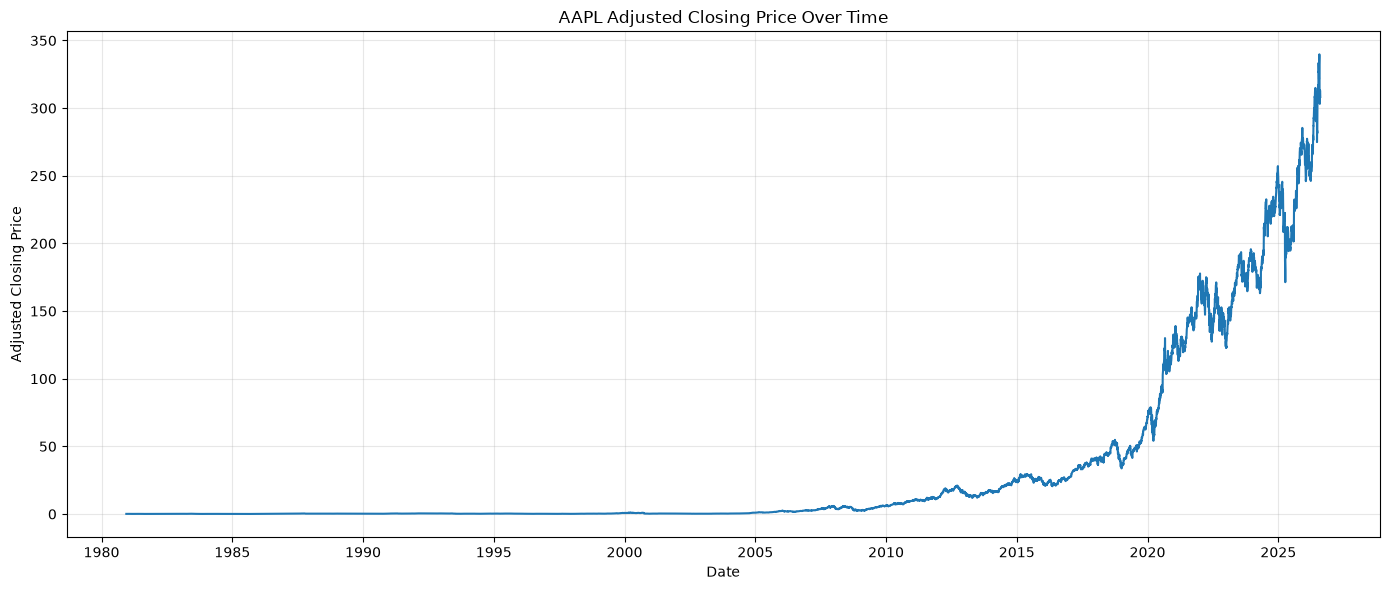

In [186]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    aapl_analysis["Date"],
    aapl_analysis["Adj Close"]
)

ax.set_title("AAPL Adjusted Closing Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Closing Price")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "08_adjusted_close_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

#### 6.3.1 Long-Term Price Trend — Initial Observation

The long-term adjusted closing price series shows substantial growth in AAPL's share price over the historical period. Price appreciation becomes particularly pronounced in the later years of the dataset, while earlier price movements appear compressed because of the large difference in price scale.

The linear-scale visualization provides a useful overview of the long-term trend but limits visibility into earlier-period movements. A logarithmic-scale view will therefore be used as a complementary visualization rather than replacing the original chart.

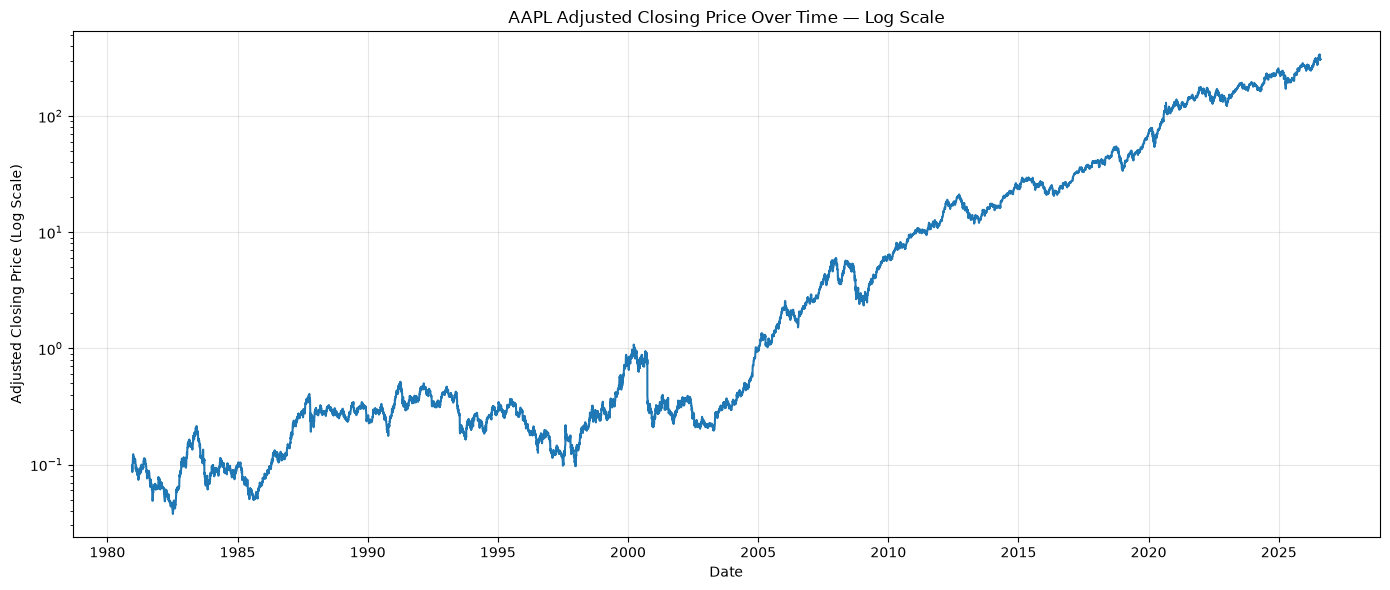

In [187]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    aapl_analysis["Date"],
    aapl_analysis["Adj Close"]
)

ax.set_yscale("log")

ax.set_title("AAPL Adjusted Closing Price Over Time — Log Scale")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Closing Price (Log Scale)")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "07_adjusted_close_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.3 Distribution of Daily Returns

Daily returns are examined to understand the typical magnitude of AAPL's day-to-day price movements and to identify the presence of extreme positive or negative observations.

A histogram is used because it allows the distribution, concentration, spread and potential tails of daily returns to be assessed visually.

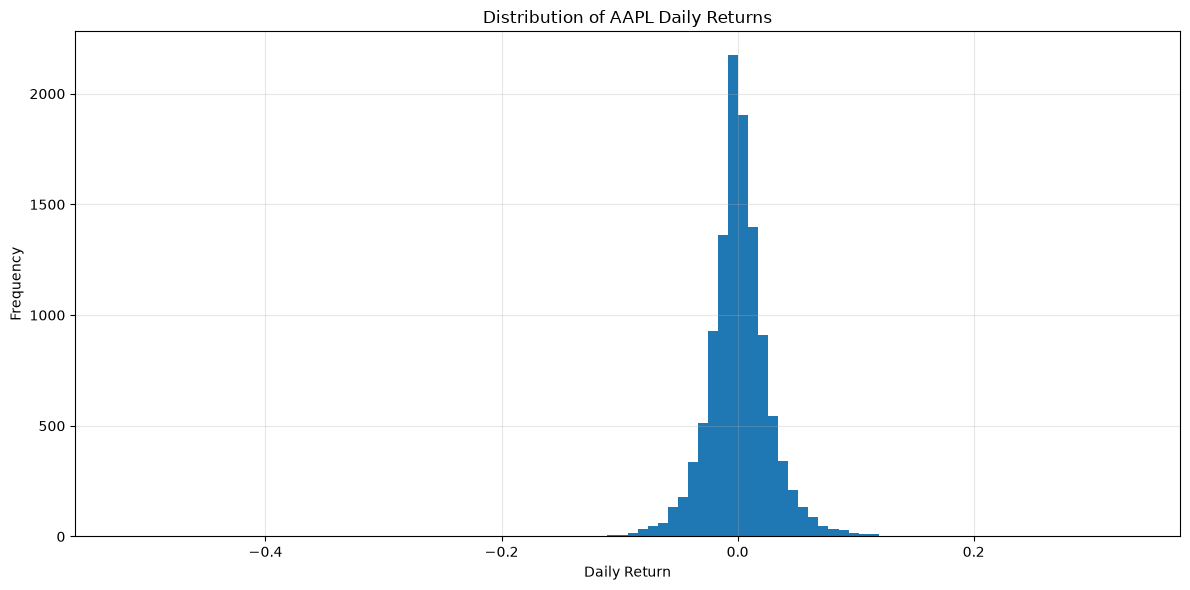

In [188]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    aapl_analysis["Daily_Return"].dropna(),
    bins=100
)

ax.set_title("Distribution of AAPL Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "06_daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.4 Daily Return Distribution Summary

The distribution of daily returns is quantified using descriptive statistics and selected percentiles to assess the central tendency, dispersion and tails of daily price movements.

This provides numerical context for the distribution observed in the histogram and helps identify the typical range of daily returns and the presence of extreme observations.

In [144]:
return_summary = aapl_analysis["Daily_Return"].dropna().describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print(return_summary)

count    11505.000000
mean         0.001086
std          0.027535
min         -0.518692
1%          -0.070204
5%          -0.040222
25%         -0.012370
50%          0.000046
75%          0.014129
95%          0.044014
99%          0.077116
max          0.332280
Name: Daily_Return, dtype: float64


### 6.3.5 Daily Return Distribution Findings

The daily-return distribution is highly concentrated around zero, indicating that most trading days produced relatively small price movements.

The mean daily return was approximately 0.109%, while the median was approximately 0.005%, indicating that the average return was influenced upward by larger positive observations.

The middle 50% of daily returns ranged from approximately -1.24% to +1.41%. However, the distribution also contained substantially larger movements, with the 1st and 99th percentiles at approximately -7.02% and +7.71%, respectively.

The observed minimum and maximum returns were -51.87% and +33.23%, indicating the presence of extreme daily movements that extend well beyond the central distribution.

These results suggest that AAPL's daily returns are concentrated near zero but include meaningful tail observations. Further analysis is required to determine the extent and characteristics of return asymmetry and extreme movements.

### 6.3.6 20-Day Rolling Volatility Over Time

The 20-day rolling volatility is visualized to examine how AAPL's short-term return variability changes over time.

Unlike the long-term price charts, this visualization focuses on the changing level of market variability rather than the absolute price level. Periods of elevated volatility may indicate unusually large or frequent daily price movements.

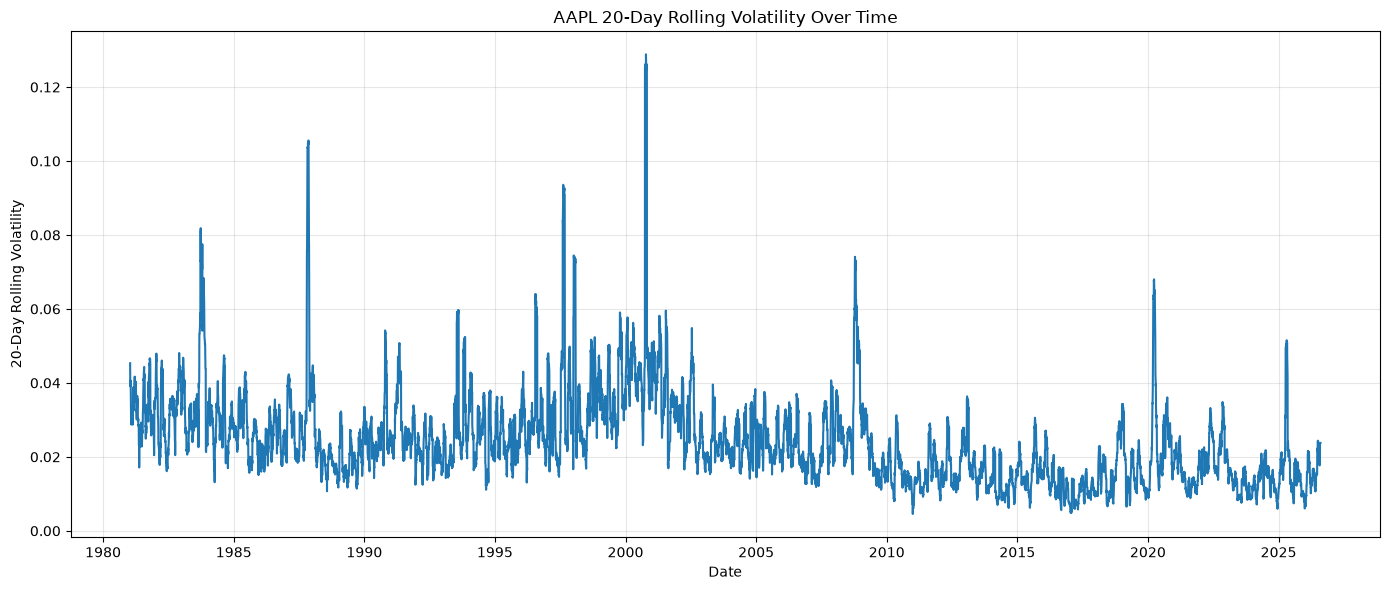

In [189]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    aapl_analysis["Date"],
    aapl_analysis["Volatility_20"]
)

ax.set_title("AAPL 20-Day Rolling Volatility Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("20-Day Rolling Volatility")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "05_20_day_rolling_volatility_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.7 Volatility Extremes

The highest observed values of 20-day rolling volatility are examined to identify periods in which AAPL experienced unusually elevated short-term return variability.

The analysis focuses on the dates and volatility levels associated with the largest observations rather than assuming that visual spikes alone represent meaningful market events.

In [146]:
top_volatility = (
    aapl_analysis[["Date", "Volatility_20"]]
    .dropna()
    .sort_values("Volatility_20", ascending=False)
    .head(10)
)

print(top_volatility.to_string(index=False))

      Date  Volatility_20
2000-10-13       0.128855
2000-10-04       0.126181
2000-10-25       0.126124
2000-10-24       0.126088
2000-10-23       0.125810
2000-09-29       0.125221
2000-10-20       0.125217
2000-10-16       0.125115
2000-10-17       0.125047
2000-10-12       0.124805


### 6.3.6 Top 10 Highest-Volatility Trading Days

A bar chart of the 10 trading days with the highest 20-day rolling volatility is used to identify periods of unusually elevated market risk.

This complements the daily-return distribution by showing when volatility was most concentrated rather than only showing the overall distribution of returns.

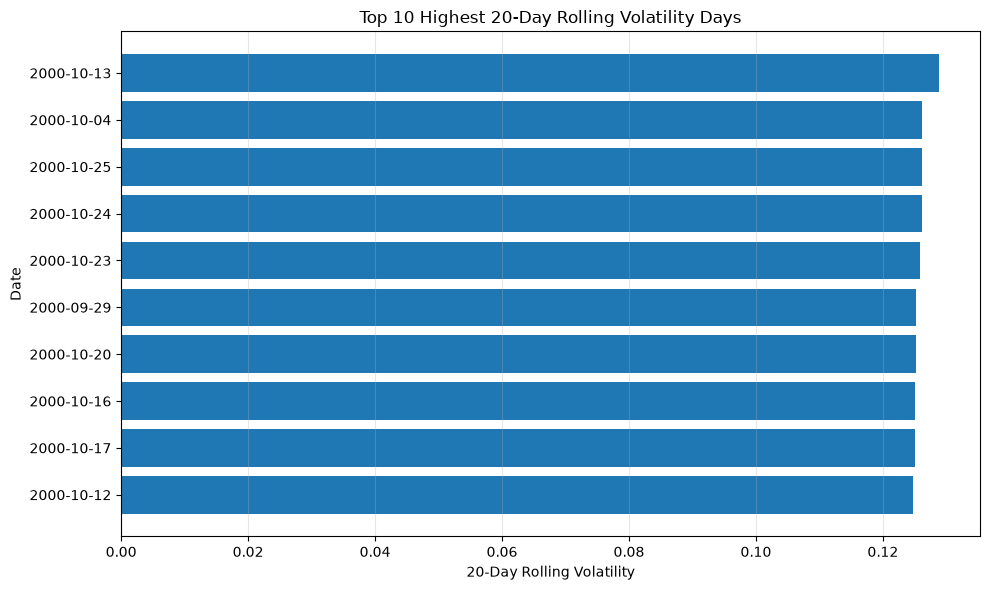

In [190]:
from pathlib import Path
import matplotlib.pyplot as plt

top_volatility = (
    aapl_analysis[["Date", "Volatility_20"]]
    .dropna()
    .nlargest(10, "Volatility_20")
    .sort_values("Volatility_20")
)

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_volatility["Date"].dt.strftime("%Y-%m-%d"),
    top_volatility["Volatility_20"]
)

ax.set_title("Top 10 Highest 20-Day Rolling Volatility Days")
ax.set_xlabel("20-Day Rolling Volatility")
ax.set_ylabel("Date")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "04_top_10_highest_volatility_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.7 Trading Volume vs. Daily Returns

A scatter plot is used to examine the relationship between daily trading volume and daily returns.

This helps assess whether periods of unusually high trading activity tend to coincide with larger daily price movements. The analysis is exploratory and does not establish causation.

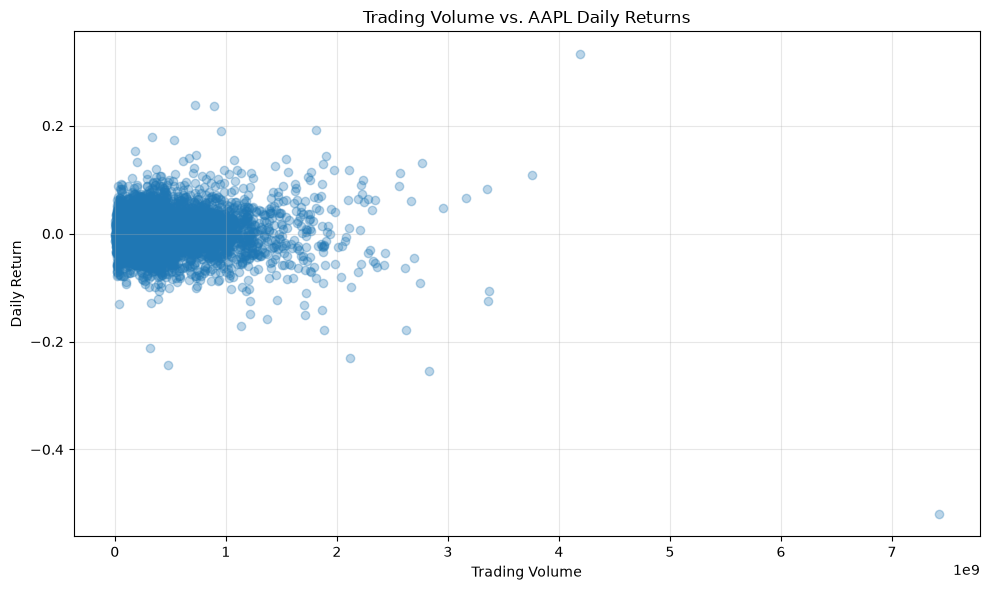

In [191]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    aapl_analysis["Volume"],
    aapl_analysis["Daily_Return"],
    alpha=0.3
)

ax.set_title("Trading Volume vs. AAPL Daily Returns")
ax.set_xlabel("Trading Volume")
ax.set_ylabel("Daily Return")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "03_volume_vs_daily_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.8 Volume–Return Relationship Validation

The scatter plot suggests that daily returns are widely dispersed across trading-volume levels, with several extreme observations occurring at high volume.

A correlation analysis will be used to quantify the linear association between trading volume and daily returns. Because financial volume data are highly skewed and extreme observations are present, the result will be interpreted alongside the scatter plot rather than treated as evidence of causation.

In [149]:
volume_return_corr = aapl_analysis[
    ["Volume", "Daily_Return"]
].dropna().corr()

print("Pearson correlation between Volume and Daily Return:")
print(volume_return_corr)

Pearson correlation between Volume and Daily Return:
                Volume  Daily_Return
Volume        1.000000      0.000944
Daily_Return  0.000944      1.000000


### 6.5 Annual Return Analysis

Annual returns are examined to evaluate how AAPL's price performance varied across calendar years. This provides a higher-level view of periods of strong growth and decline that may be difficult to identify from daily observations alone.

In [150]:
annual_performance = (
    aapl_analysis
    .set_index("Date")["Adj Close"]
    .resample("YE")
    .agg(["first", "last"])
)

annual_performance["Annual_Return"] = (
    annual_performance["last"] / annual_performance["first"] - 1
)

annual_performance = annual_performance.reset_index()

annual_performance["Year"] = annual_performance["Date"].dt.year

annual_performance.head()

,Date,first,last,Annual_Return,Year
0,1980-12-31,0.098122,0.116467,0.186961,1980
1,1981-12-31,0.117747,0.075512,-0.358698,1981
2,1982-12-31,0.075085,0.101962,0.357963,1982
3,1983-12-31,0.097269,0.083191,-0.144735,1983
4,1984-12-31,0.087457,0.099402,0.136586,1984


### 6.3.7 Annual Returns

Annual returns are examined to compare AAPL's year-over-year performance and identify periods of strong gains and declines. A bar chart is used to make positive and negative annual performance easier to compare across years.

Note that 1980 and 2026 represent partial calendar years in the dataset and should therefore be interpreted separately from complete years.

In [151]:
annual_returns_corrected = (
    aapl_analysis
    .assign(Year=aapl_analysis["Date"].dt.year)
    .groupby("Year")
    .agg(
        Year_End_Adj_Close=("Adj Close", "last")
    )
    .reset_index()
)

annual_returns_corrected["Annual_Return"] = (
    annual_returns_corrected["Year_End_Adj_Close"]
    .pct_change()
)

annual_returns_corrected.head()

,Year,Year_End_Adj_Close,Annual_Return
0,1980,0.116467,NaN
1,1981,0.075512,-0.351651
2,1982,0.101962,0.350291
3,1983,0.083191,-0.184103
4,1984,0.099402,0.194868


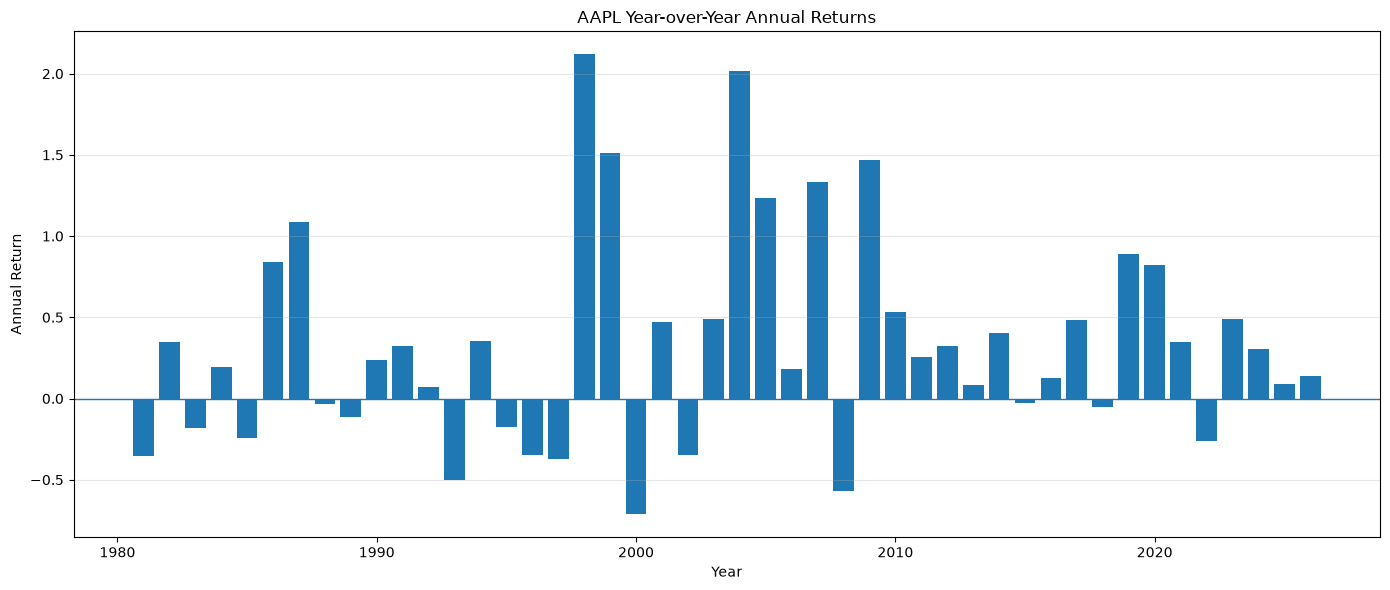

In [192]:
from pathlib import Path
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    annual_returns_corrected["Year"],
    annual_returns_corrected["Annual_Return"]
)

ax.axhline(0, linewidth=1)

ax.set_title("AAPL Year-over-Year Annual Returns")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Return")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "02_annual_return_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.8 Drawdown Analysis

Drawdown measures the decline in AAPL's adjusted closing price from a previous running peak. This analysis helps identify periods of sustained price decline and quantify the depth of historical losses from peak levels.

The running peak is calculated using the highest adjusted closing price observed up to each date. Drawdown is then calculated as the percentage difference between the current adjusted closing price and its corresponding running peak.

In [153]:
aapl_analysis["Running_Peak"] = (
    aapl_analysis["Adj Close"].cummax()
)

aapl_analysis["Drawdown"] = (
    aapl_analysis["Adj Close"] /
    aapl_analysis["Running_Peak"]
) - 1

aapl_analysis[
    ["Date", "Adj Close", "Running_Peak", "Drawdown"]
].head(25)

,Date,Adj Close,Running_Peak,Drawdown
0,1980-12-12,0.098122,0.098122,0.000000
1,1980-12-15,0.093003,0.098122,-0.052170
2,1980-12-16,0.086177,0.098122,-0.121739
3,1980-12-17,0.088310,0.098122,-0.100001
4,1980-12-18,0.090870,0.098122,-0.073908
5,1980-12-19,0.096416,0.098122,-0.017390
6,1980-12-22,0.101109,0.101109,0.000000
7,1980-12-23,0.105375,0.105375,0.000000
8,1980-12-24,0.110921,0.110921,0.000000
9,1980-12-26,0.121160,0.121160,0.000000


In [154]:
max_drawdown = aapl_analysis["Drawdown"].min()

max_drawdown_date = aapl_analysis.loc[
    aapl_analysis["Drawdown"].idxmin(),
    "Date"
]

max_drawdown_peak = aapl_analysis.loc[
    aapl_analysis["Drawdown"].idxmin(),
    "Running_Peak"
]

print(f"Maximum drawdown: {max_drawdown:.2%}")
print(f"Maximum drawdown date: {max_drawdown_date.date()}")
print(f"Peak price before maximum drawdown: {max_drawdown_peak:.6f}")

Maximum drawdown: -81.80%
Maximum drawdown date: 2003-04-17
Peak price before maximum drawdown: 1.078149


### 6.3.9 Drawdown Analysis

Drawdown measures the percentage decline in adjusted closing price from the previous running peak. This helps identify periods of significant sustained losses and assess the historical downside risk experienced by investors.

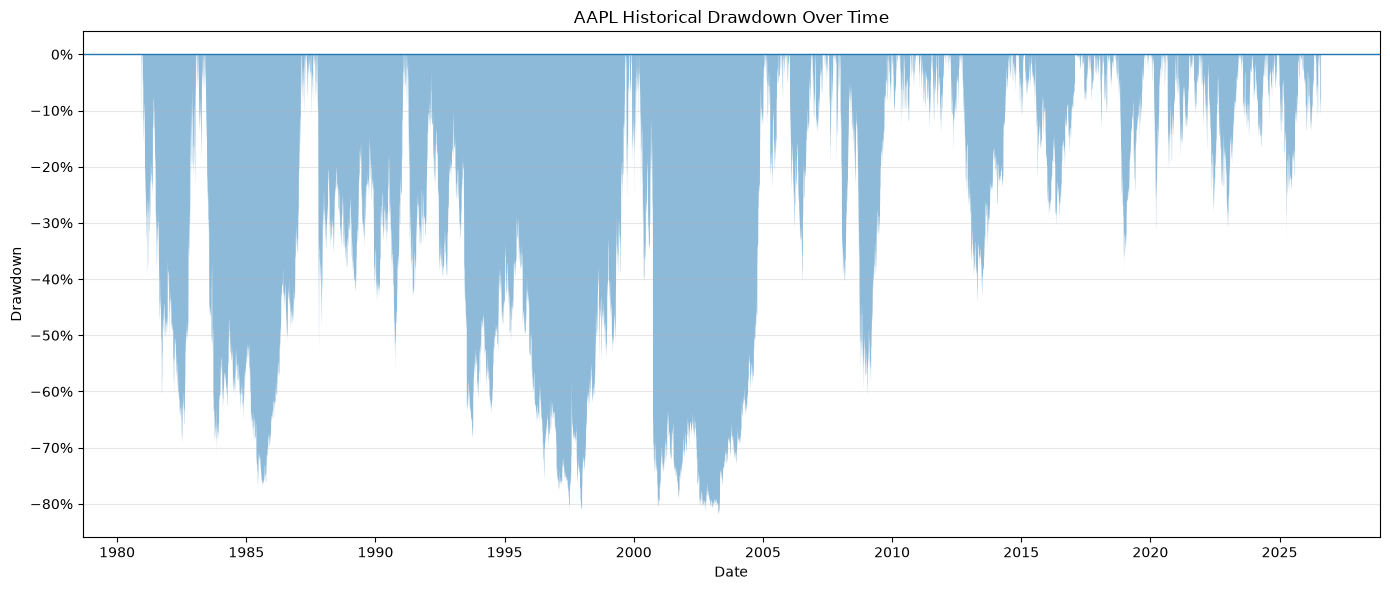

In [193]:
from pathlib import Path
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Visualizations"
output_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(
    aapl_analysis["Date"],
    aapl_analysis["Drawdown"],
    0,
    alpha=0.5
)

ax.axhline(0, linewidth=1)

ax.set_title("AAPL Historical Drawdown Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_folder / "01_drawdown_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### 6.3.10 Largest Drawdown Events

The largest drawdown observations are examined to identify the periods in which AAPL experienced the greatest declines from previous running peaks. This provides a more detailed view of historical downside risk beyond the single maximum drawdown.

In [156]:
top_drawdowns = (
    aapl_analysis[
        ["Date", "Adj Close", "Running_Peak", "Drawdown"]
    ]
    .nsmallest(10, "Drawdown")
    .reset_index(drop=True)
)

top_drawdowns

,Date,Adj Close,Running_Peak,Drawdown
0,2003-04-17,0.196207,1.078149,-0.818014
1,2003-04-21,0.196506,1.078149,-0.817737
2,2003-04-11,0.197403,1.078149,-0.816905
3,2003-04-16,0.198002,1.078149,-0.816350
4,2003-04-25,0.199647,1.078149,-0.814824
5,2003-04-15,0.200245,1.078149,-0.814270
6,2003-04-24,0.200993,1.078149,-0.813576
7,2003-04-22,0.202040,1.078149,-0.812605
8,1997-12-23,0.096739,0.515651,-0.812395
9,2003-04-14,0.203086,1.078149,-0.811634


### 6.3.11 Top 10 Largest Drawdown Troughs

To identify the most severe points of historical decline, the 10 largest drawdown observations are ranked by their percentage decline from the corresponding running peak.

This analysis helps quantify downside risk and identify the historical points at which AAPL experienced its most substantial declines from previous price peaks.

In [157]:
# Identify periods where the stock is below its running peak
drawdown_data = aapl_analysis[
    ["Date", "Adj Close", "Running_Peak", "Drawdown"]
].copy()

drawdown_data["In_Drawdown"] = drawdown_data["Drawdown"] < 0

# Identify the start of each new drawdown episode
drawdown_data["Episode"] = (
    drawdown_data["In_Drawdown"]
    & ~drawdown_data["In_Drawdown"].shift(1, fill_value=False)
).cumsum()

# Keep only observations that are actually in a drawdown
drawdown_periods = drawdown_data[
    drawdown_data["In_Drawdown"]
].copy()

# Find the worst point within each drawdown episode
major_drawdowns = (
    drawdown_periods
    .loc[
        drawdown_periods.groupby("Episode")["Drawdown"].idxmin()
    ]
    .sort_values("Drawdown")
    .head(10)
    .reset_index(drop=True)
)

major_drawdowns[
    ["Date", "Adj Close", "Running_Peak", "Drawdown"]
]

,Date,Adj Close,Running_Peak,Drawdown
0,2003-04-17,0.196207,1.078149,-0.818014
1,1997-12-23,0.096739,0.515651,-0.812395
2,1985-08-15,0.049488,0.214163,-0.768925
3,1982-07-08,0.037542,0.122866,-0.694445
4,2009-01-20,2.338933,5.976842,-0.608667
5,1990-10-16,0.176238,0.405575,-0.565461
6,2013-04-19,11.853021,21.089716,-0.437972
7,2006-07-14,1.515521,2.559965,-0.407992
8,2019-01-03,33.707924,54.823822,-0.385159
9,2025-04-08,171.365967,257.153839,-0.333605


### 6.3.12 Drawdown Duration

Drawdown duration measures how long AAPL remained below its previous running peak during each distinct drawdown episode.

The analysis records the start of each drawdown, the trough date, the maximum drawdown, and the number of trading observations and calendar days spent below the previous peak.

Because the dataset ends on 2026-08-07, any drawdown that has not yet recovered by the end of the dataset is treated as an ongoing drawdown rather than a completed recovery period.

In [158]:
drawdown_data = aapl_analysis[
    ["Date", "Adj Close", "Running_Peak", "Drawdown"]
].copy()

drawdown_data["In_Drawdown"] = drawdown_data["Drawdown"] < 0

# Identify the beginning of each drawdown episode
drawdown_data["Episode_Start"] = (
    drawdown_data["In_Drawdown"]
    & ~drawdown_data["In_Drawdown"].shift(1, fill_value=False)
)

drawdown_data["Episode"] = (
    drawdown_data["Episode_Start"].cumsum()
)

# Only observations inside drawdown periods
drawdown_observations = drawdown_data[
    drawdown_data["In_Drawdown"]
].copy()

# Basic episode summary
drawdown_summary = (
    drawdown_observations
    .groupby("Episode")
    .agg(
        Start_Date=("Date", "min"),
        Last_Drawdown_Date=("Date", "max"),
        Trading_Days_In_Drawdown=("Date", "count"),
        Maximum_Drawdown=("Drawdown", "min")
    )
    .reset_index()
)

# Date of maximum drawdown within each episode
trough_dates = (
    drawdown_observations
    .loc[
        drawdown_observations.groupby("Episode")["Drawdown"].idxmin(),
        ["Episode", "Date"]
    ]
    .rename(columns={"Date": "Trough_Date"})
)

drawdown_summary = drawdown_summary.merge(
    trough_dates,
    on="Episode",
    how="left"
)

# Calendar duration spent below the previous peak
drawdown_summary["Calendar_Days_In_Drawdown"] = (
    drawdown_summary["Last_Drawdown_Date"]
    - drawdown_summary["Start_Date"]
).dt.days

# Determine whether the drawdown is still ongoing
last_date = aapl_analysis["Date"].max()

drawdown_summary["Ongoing"] = (
    drawdown_summary["Last_Drawdown_Date"] == last_date
)

# Rank by time spent in drawdown
longest_drawdowns = (
    drawdown_summary
    .sort_values(
        "Trading_Days_In_Drawdown",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

longest_drawdowns

,Episode,Start_Date,Last_Drawdown_Date,Trading_Days_In_Drawdown,Maximum_Drawdown,Trough_Date,Calendar_Days_In_Drawdown,Ongoing
0,38,1991-04-03,1999-09-01,2128,-0.812395,1997-12-23,3073,False
1,48,2000-03-23,2005-01-25,1216,-0.818014,2003-04-17,1769,False
2,11,1983-06-07,1987-02-13,934,-0.768925,1985-08-15,1347,False
3,31,1987-10-06,1991-02-04,843,-0.565461,1990-10-16,1217,False
4,2,1980-12-30,1983-01-19,521,-0.694445,1982-07-08,750,False
5,94,2007-12-31,2009-10-20,456,-0.608667,2009-01-20,659,False
6,144,2012-09-20,2014-07-11,453,-0.437972,2013-04-19,659,False
7,161,2015-05-26,2017-01-31,426,-0.304438,2016-05-12,616,False
8,234,2022-01-04,2023-06-01,354,-0.309128,2023-01-05,513,False
9,191,2018-10-04,2019-10-09,255,-0.385159,2019-01-03,370,False


### 6.3.13 Drawdown Recovery Duration

Recovery duration measures the time between the trough of a drawdown episode and the subsequent recovery to the previous running peak.

This helps distinguish drawdowns that recovered relatively quickly from those that required prolonged recovery periods.

In [159]:
# Start from the drawdown data created in 6.3.12
recovery_data = drawdown_data.copy()

# Identify the trough observation for each drawdown episode
trough_indices = (
    drawdown_observations
    .groupby("Episode")["Drawdown"]
    .idxmin()
)

trough_info = (
    recovery_data
    .loc[
        trough_indices,
        ["Episode", "Date", "Drawdown"]
    ]
    .rename(
        columns={
            "Date": "Trough_Date",
            "Drawdown": "Maximum_Drawdown"
        }
    )
)

# Identify the last observation below the previous peak
last_drawdown_indices = (
    drawdown_observations
    .groupby("Episode")["Date"]
    .idxmax()
)

last_drawdown_info = (
    recovery_data
    .loc[
        last_drawdown_indices,
        ["Episode", "Date"]
    ]
    .rename(
        columns={"Date": "Last_Drawdown_Date"}
    )
)

# Combine trough and last-drawdown information
recovery_summary = trough_info.merge(
    last_drawdown_info,
    on="Episode",
    how="left"
)

# Find the first trading day after the drawdown ends
recovery_dates = []

for _, row in recovery_summary.iterrows():
    episode = row["Episode"]
    last_date = row["Last_Drawdown_Date"]

    next_observation = recovery_data[
        (recovery_data["Episode"] == episode) &
        (recovery_data["Date"] > last_date)
    ]

    if len(next_observation) > 0:
        recovery_date = next_observation["Date"].iloc[0]
    else:
        recovery_date = pd.NaT

    recovery_dates.append(recovery_date)

recovery_summary["Recovery_Date"] = recovery_dates

# Determine whether recovery actually occurred
recovery_summary["Recovered"] = (
    recovery_summary["Recovery_Date"].notna()
)

# Calculate calendar recovery duration
recovery_summary["Recovery_Calendar_Days"] = (
    recovery_summary["Recovery_Date"]
    - recovery_summary["Trough_Date"]
).dt.days

# Calculate trading-day recovery duration
trading_day_positions = pd.Series(
    recovery_data.index,
    index=recovery_data["Date"]
)

recovery_summary["Recovery_Trading_Days"] = (
    recovery_summary["Recovery_Date"].map(trading_day_positions)
    - recovery_summary["Trough_Date"].map(trading_day_positions)
)

# Display the longest completed recovery periods
longest_recoveries = (
    recovery_summary[
        recovery_summary["Recovered"]
    ]
    .sort_values(
        "Recovery_Trading_Days",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

longest_recoveries

,Episode,Trough_Date,Maximum_Drawdown,Last_Drawdown_Date,Recovery_Date,Recovered,Recovery_Calendar_Days,Recovery_Trading_Days
0,48,2003-04-17,-0.818014,2005-01-25,2005-01-26,True,650.0,447.0
1,38,1997-12-23,-0.812395,1999-09-01,1999-09-02,True,618.0,426.0
2,11,1985-08-15,-0.768925,1987-02-13,1987-02-17,True,551.0,379.0
3,144,2013-04-19,-0.437972,2014-07-11,2014-07-14,True,451.0,310.0
4,191,2019-01-03,-0.385159,2019-10-09,2019-10-10,True,280.0,194.0
5,94,2009-01-20,-0.608667,2009-10-20,2009-10-21,True,274.0,191.0
6,161,2016-05-12,-0.304438,2017-01-31,2017-02-01,True,265.0,182.0
7,2,1982-07-08,-0.694445,1983-01-19,1983-01-20,True,196.0,137.0
8,252,2025-04-08,-0.333605,2025-10-17,2025-10-20,True,195.0,134.0
9,234,2023-01-05,-0.309128,2023-06-01,2023-06-02,True,148.0,102.0


In [160]:
recovery_validation = recovery_data[
    recovery_data["Date"].isin(
        longest_recoveries["Recovery_Date"]
    )
][
    ["Date", "Adj Close", "Running_Peak", "Drawdown"]
].copy()

recovery_validation

,Date,Adj Close,Running_Peak,Drawdown
532,1983-01-20,0.127560,0.127560,0.0
1561,1987-02-17,0.226535,0.226535,0.0
4732,1999-09-02,0.527624,0.527624,0.0
6088,2005-01-26,1.080485,1.080485,0.0
7281,2009-10-21,6.129082,6.129082,0.0
8469,2014-07-14,21.126972,21.126972,0.0
9113,2017-02-01,29.594442,29.594442,0.0
9790,2019-10-10,55.199547,55.199547,0.0
10707,2023-06-02,178.294495,178.294495,0.0
11304,2025-10-20,261.274841,261.274841,0.0


### 6.3.13 Recovery Duration Validation

The recovery dates were validated against the running peak. For each identified recovery date, the adjusted closing price equals the corresponding running peak and the calculated drawdown is 0%.

This confirms that the recovery duration calculation correctly identifies the point at which each drawdown episode returned to its previous peak.

### 6.3.14 Monthly Return Seasonality

Monthly return analysis was used to assess whether AAPL's historical performance varied systematically across calendar months. The analysis was restricted to complete calendar months to avoid partial-period bias.

October recorded the highest average monthly return at approximately 6.33%, with positive returns in 32 of 45 observations (71.1%). August followed with an average return of approximately 5.24% and positive returns in 31 of 45 observations (68.9%).

September recorded the lowest average monthly return at approximately -3.90% and had the lowest positive-month rate at 40.0%, with 18 positive and 27 negative observations. June also had a negative average return of approximately -2.01% and more negative than positive observations.

Overall, the results suggest historical differences in AAPL's monthly return patterns, particularly stronger performance in October and August and weaker performance in September and June. However, these historical patterns should not be interpreted as evidence of a predictable seasonal effect or as a basis for forecasting future returns.

In [161]:
# Create monthly adjusted closing prices
monthly_prices = (
    aapl_analysis
    .set_index("Date")["Adj Close"]
    .resample("ME")
    .agg(["first", "last"])
)

# Calculate monthly returns
monthly_prices["Monthly_Return"] = (
    monthly_prices["last"] / monthly_prices["first"]
) - 1

# Create calendar month fields
monthly_prices["Month_Number"] = monthly_prices.index.month
monthly_prices["Month"] = monthly_prices.index.strftime("%B")

# Aggregate monthly returns by calendar month
seasonality_summary = (
    monthly_prices
    .groupby(["Month_Number", "Month"])["Monthly_Return"]
    .agg(
        Observations="count",
        Mean_Return="mean",
        Median_Return="median",
        Std_Return="std"
    )
    .reset_index()
    .sort_values("Month_Number")
    .reset_index(drop=True)
)

seasonality_summary

,Month_Number,Month,Observations,Mean_Return,Median_Return,Std_Return
0,1,January,46,0.021683,0.014936,0.148869
1,2,February,46,0.014480,0.014786,0.100565
2,3,March,46,0.015837,-0.006355,0.102263
3,4,April,46,0.036515,0.017616,0.111168
4,5,May,46,0.019709,0.022538,0.120562
5,6,June,46,-0.020106,-0.028764,0.115852
6,7,July,46,0.030313,0.027687,0.126732
7,8,August,46,0.051650,0.054973,0.106856
8,9,September,45,-0.039007,-0.024686,0.145511
9,10,October,45,0.063298,0.057862,0.146582


In [162]:
# Identify the first and last dates in the dataset
first_date = aapl_analysis["Date"].min()
last_date = aapl_analysis["Date"].max()

# Remove the incomplete first and last calendar months
complete_monthly_prices = monthly_prices[
    (monthly_prices.index.to_period("M") > first_date.to_period("M")) &
    (monthly_prices.index.to_period("M") < last_date.to_period("M"))
].copy()

# Recalculate seasonality using complete calendar months only
seasonality_summary_complete = (
    complete_monthly_prices
    .groupby(["Month_Number", "Month"])["Monthly_Return"]
    .agg(
        Observations="count",
        Mean_Return="mean",
        Median_Return="median",
        Std_Return="std"
    )
    .reset_index()
    .sort_values("Month_Number")
    .reset_index(drop=True)
)

seasonality_summary_complete

,Month_Number,Month,Observations,Mean_Return,Median_Return,Std_Return
0,1,January,46,0.021683,0.014936,0.148869
1,2,February,46,0.014480,0.014786,0.100565
2,3,March,46,0.015837,-0.006355,0.102263
3,4,April,46,0.036515,0.017616,0.111168
4,5,May,46,0.019709,0.022538,0.120562
5,6,June,46,-0.020106,-0.028764,0.115852
6,7,July,46,0.030313,0.027687,0.126732
7,8,August,45,0.052424,0.060005,0.107933
8,9,September,45,-0.039007,-0.024686,0.145511
9,10,October,45,0.063298,0.057862,0.146582


In [163]:
monthly_consistency = (
    complete_monthly_prices
    .assign(
        Positive_Month=lambda x: x["Monthly_Return"] > 0
    )
    .groupby(["Month_Number", "Month"])
    .agg(
        Observations=("Monthly_Return", "count"),
        Positive_Months=("Positive_Month", "sum"),
        Negative_Months=("Positive_Month", lambda x: (~x).sum()),
        Mean_Return=("Monthly_Return", "mean"),
        Median_Return=("Monthly_Return", "median")
    )
    .reset_index()
)

monthly_consistency["Positive_Month_Rate"] = (
    monthly_consistency["Positive_Months"]
    / monthly_consistency["Observations"]
)

monthly_consistency = (
    monthly_consistency
    .sort_values("Month_Number")
    .reset_index(drop=True)
)

monthly_consistency

,Month_Number,Month,Observations,Positive_Months,Negative_Months,Mean_Return,Median_Return,Positive_Month_Rate
0,1,January,46,24,22,0.021683,0.014936,0.521739
1,2,February,46,25,21,0.014480,0.014786,0.543478
2,3,March,46,22,24,0.015837,-0.006355,0.478261
3,4,April,46,27,19,0.036515,0.017616,0.586957
4,5,May,46,27,19,0.019709,0.022538,0.586957
5,6,June,46,21,25,-0.020106,-0.028764,0.456522
6,7,July,46,29,17,0.030313,0.027687,0.630435
7,8,August,45,31,14,0.052424,0.060005,0.688889
8,9,September,45,18,27,-0.039007,-0.024686,0.400000
9,10,October,45,32,13,0.063298,0.057862,0.711111


### 6.3.15 Daily Return Distribution

The distribution of daily returns was examined to understand the typical range of AAPL's daily price movements and the frequency and magnitude of unusually large gains and losses.

Across 11,504 valid daily return observations, the mean daily return was approximately 0.11%, while the median was approximately 0.005%. The standard deviation was 2.75%, indicating substantial day-to-day variation.

Daily returns were positive on 50.02% of trading days and negative on 46.76%, with 371 observations recording a zero return. Returns of at least +5% occurred on 422 days, compared with 334 days at or below -5%.

The return distribution had a skewness of -0.364, indicating moderate negative skew. Although extreme positive returns were more frequent and had a similar average magnitude to extreme negative returns, the most severe negative observation (-51.87%) was substantially larger in absolute magnitude than the largest positive observation (+33.23%). This pronounced downside extreme contributes to the negative skewness observed in the distribution.

These results indicate that AAPL's historical daily returns were generally concentrated around zero but included substantial tail events, particularly on the downside.

In [164]:
# Analyze the distribution of daily returns
return_distribution = aapl_analysis["Daily_Return"].dropna()

distribution_summary = return_distribution.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

# Additional distribution measures
skewness = return_distribution.skew()

negative_return_rate = (
    (return_distribution < 0).mean()
)

positive_return_rate = (
    (return_distribution > 0).mean()
)

zero_return_count = (
    (return_distribution == 0).sum()
)

# Count extreme daily movements
extreme_negative_count = (
    (return_distribution <= -0.05).sum()
)

extreme_positive_count = (
    (return_distribution >= 0.05).sum()
)

print("Daily return distribution summary:")
print(distribution_summary)

print("\nSkewness:", skewness)
print(
    f"Negative return rate: {negative_return_rate:.2%}"
)
print(
    f"Positive return rate: {positive_return_rate:.2%}"
)
print(
    f"Zero-return observations: {zero_return_count}"
)
print(
    f"Returns <= -5%: {extreme_negative_count}"
)
print(
    f"Returns >= +5%: {extreme_positive_count}"
)

Daily return distribution summary:
count    11505.000000
mean         0.001086
std          0.027535
min         -0.518692
1%          -0.070204
5%          -0.040222
25%         -0.012370
50%          0.000046
75%          0.014129
95%          0.044014
99%          0.077116
max          0.332280
Name: Daily_Return, dtype: float64

Skewness: -0.3636568737568397
Negative return rate: 46.76%
Positive return rate: 50.01%
Zero-return observations: 371
Returns <= -5%: 335
Returns >= +5%: 422


In [165]:
# Compare the magnitude of extreme positive and negative daily returns

extreme_negative = return_distribution[
    return_distribution <= -0.05
]

extreme_positive = return_distribution[
    return_distribution >= 0.05
]

tail_summary = pd.DataFrame({
    "Negative_Tail": [
        len(extreme_negative),
        extreme_negative.mean(),
        extreme_negative.median(),
        extreme_negative.min()
    ],
    "Positive_Tail": [
        len(extreme_positive),
        extreme_positive.mean(),
        extreme_positive.median(),
        extreme_positive.max()
    ]
}, index=[
    "Observations",
    "Mean_Return",
    "Median_Return",
    "Extreme_Return"
])

tail_summary

,Negative_Tail,Positive_Tail
Observations,335.000000,422.000000
Mean_Return,-0.072026,0.072475
Median_Return,-0.062065,0.063629
Extreme_Return,-0.518692,0.332280


### 6.3.16 Volume and Return Relationship

The relationship between trading volume and daily returns was examined from two perspectives: return direction and return magnitude.

Pearson correlation between trading volume and daily return was approximately 0.001, indicating essentially no linear relationship between trading activity and whether AAPL's daily return was positive or negative.

In contrast, the correlation between trading volume and absolute daily return was approximately 0.384, indicating a moderate positive relationship between trading activity and the magnitude of daily price movements.

To further evaluate this relationship, trading days were divided into four equally sized volume groups. Mean absolute daily return increased progressively from approximately 1.24% in the lowest-volume group to 2.67% in the highest-volume group. Median absolute return showed the same pattern, increasing from approximately 0.85% to 1.88%.

These results suggest that higher trading volume was historically associated with larger daily price movements, regardless of direction. The analysis establishes an association rather than a causal relationship.

In [166]:
# Prepare data for volume-return relationship analysis
volume_return = aapl_analysis[
    ["Volume", "Daily_Return"]
].dropna().copy()

# Measure return magnitude
volume_return["Absolute_Return"] = (
    volume_return["Daily_Return"].abs()
)

# Pearson correlations
direction_correlation = volume_return[
    ["Volume", "Daily_Return"]
].corr().loc["Volume", "Daily_Return"]

magnitude_correlation = volume_return[
    ["Volume", "Absolute_Return"]
].corr().loc["Volume", "Absolute_Return"]

print(
    f"Pearson correlation between Volume and Daily Return: "
    f"{direction_correlation:.6f}"
)

print(
    f"Pearson correlation between Volume and Absolute Daily Return: "
    f"{magnitude_correlation:.6f}"
)

Pearson correlation between Volume and Daily Return: 0.000944
Pearson correlation between Volume and Absolute Daily Return: 0.383824


In [167]:
# Divide trading days into volume quartiles
volume_return["Volume_Quartile"] = pd.qcut(
    volume_return["Volume"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

# Compare return magnitude across volume groups
volume_impact_summary = (
    volume_return
    .groupby("Volume_Quartile", observed=True)
    .agg(
        Observations=("Absolute_Return", "count"),
        Mean_Absolute_Return=("Absolute_Return", "mean"),
        Median_Absolute_Return=("Absolute_Return", "median"),
        Mean_Return=("Daily_Return", "mean")
    )
    .reset_index()
)

volume_impact_summary

,Volume_Quartile,Observations,Mean_Absolute_Return,Median_Absolute_Return,Mean_Return
0,Low,2877,0.012449,0.008547,0.000003
1,Medium-Low,2876,0.015759,0.012657,0.000208
2,Medium-High,2876,0.020399,0.015438,0.001296
3,High,2876,0.026717,0.018806,0.002835


### 6.3.17 Extreme Daily Return Analysis

The largest positive and negative daily returns were identified to examine the most extreme one-day price movements in AAPL's historical record.

The largest positive daily return in the dataset occurred on 6 August 1997, when AAPL's adjusted closing price increased by approximately 33.23%. The largest negative daily return occurred on 29 September 2000, when the adjusted closing price declined by approximately 51.87%.

Several other substantial daily movements occurred throughout the historical period, including multiple large positive and negative returns during October 1987. The presence of these observations demonstrates that AAPL's historical daily returns included occasional extreme movements substantially outside the typical range of daily returns.

These observations provide context for the wide range and negative skewness identified in the daily return distribution. The analysis identifies the magnitude and timing of extreme movements but does not establish the external causes of those movements.

In [168]:
# Identify the 10 largest positive and negative daily returns

extreme_returns = aapl_analysis[
    ["Date", "Adj Close", "Daily_Return"]
].dropna(subset=["Daily_Return"]).copy()

top_positive_returns = (
    extreme_returns
    .nlargest(10, "Daily_Return")
    .reset_index(drop=True)
)

top_negative_returns = (
    extreme_returns
    .nsmallest(10, "Daily_Return")
    .reset_index(drop=True)
)

print("Top 10 largest positive daily returns:")
display(top_positive_returns)

print("\nTop 10 largest negative daily returns:")
display(top_negative_returns)

Top 10 largest positive daily returns:


,Date,Adj Close,Daily_Return
0,1997-08-06,0.196749,0.332280
1,1998-01-02,0.121508,0.238087
2,1996-07-18,0.156091,0.237034
3,1998-01-06,0.141604,0.192915
4,1993-10-15,0.205214,0.189470
5,1987-10-29,0.270384,0.179107
6,1987-10-21,0.277228,0.173912
7,2025-04-09,197.634399,0.153289
8,1997-07-11,0.113563,0.146225
9,1999-10-14,0.547253,0.142996



Top 10 largest negative daily returns:


,Date,Adj Close,Daily_Return
0,2000-09-29,0.385086,-0.518692
1,1983-09-23,0.082764,-0.253844
2,1987-10-19,0.249848,-0.243524
3,1993-07-16,0.198891,-0.230767
4,1987-10-26,0.191664,-0.211267
5,2008-09-29,3.148288,-0.179195
6,1997-01-06,0.133659,-0.178160
7,2001-07-18,0.310911,-0.171712
8,2000-12-06,0.214041,-0.158088
9,2002-06-19,0.256026,-0.150373


# 7. Key Findings and Conclusions

## 7.1 Key Findings

The analysis of AAPL historical stock data revealed several important patterns in price performance, volatility, trading activity, and downside risk.

1. **Long-term price growth:** AAPL's adjusted closing price increased substantially over the historical period, although the long-term upward trend was interrupted by several major drawdown periods.

2. **Significant downside risk:** The maximum historical drawdown was approximately 81.80%, demonstrating that substantial declines from previous peaks occurred during the observed period.

3. **Volatility varies considerably over time:** The 20-day rolling volatility showed periods of substantially elevated market risk. The highest observed 20-day volatility was approximately 12.89%.

4. **Extreme daily movements were relatively uncommon:** Most daily returns were concentrated around zero, while a smaller number of observations produced exceptionally large positive or negative movements. The largest positive daily return was approximately 33.23%, while the largest negative daily return was approximately -51.87%.

5. **Negative skewness in daily returns:** Daily returns had a skewness of approximately -0.36, indicating that the distribution contained a somewhat longer or heavier negative tail than the positive side.

6. **Volume is more strongly associated with return magnitude than return direction:** The Pearson correlation between trading volume and Daily_Return was approximately 0.001, indicating almost no linear relationship between trading volume and the direction of daily returns. However, the correlation between volume and absolute daily return was approximately 0.384, suggesting that higher trading activity was more associated with larger price movements regardless of direction.

7. **Historical monthly performance varied by calendar month:** October recorded the highest average monthly return at approximately 6.33%, while September recorded the lowest at approximately -3.90%. August also showed relatively strong historical average performance at approximately 5.24%.

8. **Major drawdowns required substantial recovery periods:** Several historical drawdown episodes lasted months or years before the stock recovered to its previous peak, demonstrating that drawdown magnitude alone does not capture the full extent of downside risk; recovery duration is also important.

## 7.2 Conclusion

The analysis demonstrates that AAPL experienced substantial long-term price appreciation alongside periods of considerable volatility and severe drawdowns. Although the overall historical price trajectory was strongly upward, the stock was exposed to significant short-term and medium-term downside risk.

The analysis also shows that trading volume had almost no linear relationship with the direction of daily returns, while higher trading activity was more strongly associated with larger absolute price movements. Historical monthly returns also varied across calendar months; however, these patterns represent historical observations and should not be interpreted as reliable predictors of future performance.

Overall, the findings demonstrate the importance of evaluating both return potential and downside risk when analyzing long-term equity price behaviour. Moving averages, rolling volatility, drawdown analysis, return distributions, and volume relationships provided complementary perspectives on AAPL's historical market behaviour.

In [169]:
# Export the final analytical dataset

aapl_analysis.to_csv(
    "../04_Analysis_Output/AAPL_analytical_dataset.csv",
    index=False
)

print("Analytical dataset exported successfully.")

Analytical dataset exported successfully.


In [170]:
# Export key analytical tables

annual_returns_corrected.to_csv(
    "../04_Analysis_Output/Tables/annual_returns.csv",
    index=False
)

seasonality_summary_complete.to_csv(
    "../04_Analysis_Output/Tables/monthly_seasonality.csv",
    index=False
)

top_positive_returns.to_csv(
    "../04_Analysis_Output/Tables/top_10_positive_returns.csv",
    index=False
)

top_negative_returns.to_csv(
    "../04_Analysis_Output/Tables/top_10_negative_returns.csv",
    index=False
)

print("Key analytical tables exported successfully.")

Key analytical tables exported successfully.


In [171]:
# Export key volatility and drawdown tables

top_volatility.to_csv(
    "../04_Analysis_Output/Tables/top_10_volatility.csv",
    index=False
)

top_drawdowns.to_csv(
    "../04_Analysis_Output/Tables/top_10_drawdowns.csv",
    index=False
)

drawdown_summary.to_csv(
    "../04_Analysis_Output/Tables/drawdown_summary.csv",
    index=False
)

recovery_summary.to_csv(
    "../04_Analysis_Output/Tables/recovery_summary.csv",
    index=False
)

print("Volatility and drawdown tables exported successfully.")

Volatility and drawdown tables exported successfully.


In [172]:
import matplotlib.pyplot as plt

print("Number of open figures:", len(plt.get_fignums()))
print("Figure numbers:", plt.get_fignums())

Number of open figures: 0
Figure numbers: []


In [173]:
from pathlib import Path

project_root = Path.cwd().parent

output_folder = project_root / "04_Analysis_Output"
tables_folder = output_folder / "Tables"
visuals_folder = output_folder / "Visualizations"

print("=== ANALYSIS OUTPUT QC ===\n")

print("Main analytical dataset:")
for file in output_folder.glob("*.csv"):
    print(f"  ✓ {file.name}")

print("\nAnalytical tables:")
for file in tables_folder.glob("*.csv"):
    print(f"  ✓ {file.name}")

print("\nVisualizations:")
for file in visuals_folder.glob("*.png"):
    print(f"  ✓ {file.name}")

print("\nFolder check:")
print("Tables folder exists:", tables_folder.exists())
print("Visualizations folder exists:", visuals_folder.exists())

=== ANALYSIS OUTPUT QC ===

Main analytical dataset:
  ✓ AAPL_analytical_dataset.csv

Analytical tables:
  ✓ annual_returns.csv
  ✓ drawdown_summary.csv
  ✓ monthly_seasonality.csv
  ✓ recovery_summary.csv
  ✓ top_10_drawdowns.csv
  ✓ top_10_negative_returns.csv
  ✓ top_10_positive_returns.csv
  ✓ top_10_volatility.csv

Visualizations:
  ✓ 01_drawdown_over_time.png
  ✓ 02_annual_return_by_year.png
  ✓ 03_volume_vs_daily_return.png
  ✓ 04_top_10_highest_volatility_days.png
  ✓ 05_20_day_rolling_volatility_over_time.png
  ✓ 06_daily_return_distribution.png
  ✓ 07_adjusted_close_log_scale.png

Folder check:
Tables folder exists: True
Visualizations folder exists: True


In [174]:
# Check exported table sizes

from pathlib import Path
import pandas as pd

tables_folder = Path.cwd().parent / "04_Analysis_Output" / "Tables"

print("=== TABLE SIZE QC ===\n")

for file in sorted(tables_folder.glob("*.csv")):
    df_check = pd.read_csv(file)
    print(f"{file.name}: {df_check.shape[0]:,} rows × {df_check.shape[1]} columns")

=== TABLE SIZE QC ===

annual_returns.csv: 47 rows × 3 columns
drawdown_summary.csv: 267 rows × 8 columns
monthly_seasonality.csv: 12 rows × 6 columns
recovery_summary.csv: 267 rows × 8 columns
top_10_drawdowns.csv: 10 rows × 4 columns
top_10_negative_returns.csv: 10 rows × 3 columns
top_10_positive_returns.csv: 10 rows × 3 columns
top_10_volatility.csv: 10 rows × 2 columns


In [175]:
print("DRAWDown summary:")
display(drawdown_summary.head())
print("\nLast rows:")
display(drawdown_summary.tail())

print("\nRECOVERY summary:")
display(recovery_summary.head())
print("\nLast rows:")
display(recovery_summary.tail())

DRAWDown summary:


,Episode,Start_Date,Last_Drawdown_Date,Trading_Days_In_Drawdown,Maximum_Drawdown,Trough_Date,Calendar_Days_In_Drawdown,Ongoing
0,1,1980-12-15,1980-12-19,5,-0.121739,1980-12-16,4,False
1,2,1980-12-30,1983-01-19,521,-0.694445,1982-07-08,750,False
2,3,1983-01-24,1983-01-25,2,-0.056859,1983-01-24,1,False
3,4,1983-01-31,1983-01-31,1,-0.003048,1983-01-31,0,False
4,5,1983-02-04,1983-02-09,4,-0.061626,1983-02-08,5,False



Last rows:


,Episode,Start_Date,Last_Drawdown_Date,Trading_Days_In_Drawdown,Maximum_Drawdown,Trough_Date,Calendar_Days_In_Drawdown,Ongoing
262,263,2026-06-03,2026-07-08,24,-0.127062,2026-06-25,35,False
263,264,2026-07-10,2026-07-10,1,-0.002846,2026-07-10,0,False
264,265,2026-07-14,2026-07-14,1,-0.007721,2026-07-14,0,False
265,266,2026-07-20,2026-07-24,5,-0.036196,2026-07-23,4,False
266,267,2026-07-29,2026-08-10,9,-0.107798,2026-08-03,12,True



RECOVERY summary:


,Episode,Trough_Date,Maximum_Drawdown,Last_Drawdown_Date,Recovery_Date,Recovered,Recovery_Calendar_Days,Recovery_Trading_Days
0,1,1980-12-16,-0.121739,1980-12-19,1980-12-22,True,6.0,4.0
1,2,1982-07-08,-0.694445,1983-01-19,1983-01-20,True,196.0,137.0
2,3,1983-01-24,-0.056859,1983-01-25,1983-01-26,True,2.0,2.0
3,4,1983-01-31,-0.003048,1983-01-31,1983-02-01,True,1.0,1.0
4,5,1983-02-08,-0.061626,1983-02-09,1983-02-10,True,2.0,2.0



Last rows:


,Episode,Trough_Date,Maximum_Drawdown,Last_Drawdown_Date,Recovery_Date,Recovered,Recovery_Calendar_Days,Recovery_Trading_Days
262,263,2026-06-25,-0.127062,2026-07-08,2026-07-09,True,14.0,9.0
263,264,2026-07-10,-0.002846,2026-07-10,2026-07-13,True,3.0,1.0
264,265,2026-07-14,-0.007721,2026-07-14,2026-07-15,True,1.0,1.0
265,266,2026-07-23,-0.036196,2026-07-24,2026-07-27,True,4.0,2.0
266,267,2026-08-03,-0.107798,2026-08-10,NaT,False,NaN,NaN


In [176]:
print("Top 10 Drawdowns:")
display(top_drawdowns)

print("\nFull Drawdown Episodes:")
display(drawdown_summary.head())

print("\nRecovery Summary:")
display(recovery_summary.head())

Top 10 Drawdowns:


,Date,Adj Close,Running_Peak,Drawdown
0,2003-04-17,0.196207,1.078149,-0.818014
1,2003-04-21,0.196506,1.078149,-0.817737
2,2003-04-11,0.197403,1.078149,-0.816905
3,2003-04-16,0.198002,1.078149,-0.816350
4,2003-04-25,0.199647,1.078149,-0.814824
5,2003-04-15,0.200245,1.078149,-0.814270
6,2003-04-24,0.200993,1.078149,-0.813576
7,2003-04-22,0.202040,1.078149,-0.812605
8,1997-12-23,0.096739,0.515651,-0.812395
9,2003-04-14,0.203086,1.078149,-0.811634



Full Drawdown Episodes:


,Episode,Start_Date,Last_Drawdown_Date,Trading_Days_In_Drawdown,Maximum_Drawdown,Trough_Date,Calendar_Days_In_Drawdown,Ongoing
0,1,1980-12-15,1980-12-19,5,-0.121739,1980-12-16,4,False
1,2,1980-12-30,1983-01-19,521,-0.694445,1982-07-08,750,False
2,3,1983-01-24,1983-01-25,2,-0.056859,1983-01-24,1,False
3,4,1983-01-31,1983-01-31,1,-0.003048,1983-01-31,0,False
4,5,1983-02-04,1983-02-09,4,-0.061626,1983-02-08,5,False



Recovery Summary:


,Episode,Trough_Date,Maximum_Drawdown,Last_Drawdown_Date,Recovery_Date,Recovered,Recovery_Calendar_Days,Recovery_Trading_Days
0,1,1980-12-16,-0.121739,1980-12-19,1980-12-22,True,6.0,4.0
1,2,1982-07-08,-0.694445,1983-01-19,1983-01-20,True,196.0,137.0
2,3,1983-01-24,-0.056859,1983-01-25,1983-01-26,True,2.0,2.0
3,4,1983-01-31,-0.003048,1983-01-31,1983-02-01,True,1.0,1.0
4,5,1983-02-08,-0.061626,1983-02-09,1983-02-10,True,2.0,2.0


In [194]:
# Create Top 10 Largest Distinct Drawdown Episodes

top_10_drawdowns = (
    drawdown_summary
    .sort_values("Maximum_Drawdown", ascending=True)
    .head(10)
    .copy()
)

In [178]:
from pathlib import Path

output_folder = Path.cwd().parent / "04_Analysis_Output" / "Tables"
output_folder.mkdir(parents=True, exist_ok=True)

top_10_drawdowns.to_csv(
    output_folder / "top_10_drawdowns.csv",
    index=False
)

print("Top 10 distinct drawdown episodes exported successfully.")

Top 10 distinct drawdown episodes exported successfully.


In [179]:
display(
    top_10_drawdowns[
        [
            "Episode",
            "Start_Date",
            "Last_Drawdown_Date",
            "Trading_Days_In_Drawdown",
            "Maximum_Drawdown",
            "Trough_Date",
            "Calendar_Days_In_Drawdown",
            "Ongoing"
        ]
    ]
)

,Episode,Start_Date,Last_Drawdown_Date,Trading_Days_In_Drawdown,Maximum_Drawdown,Trough_Date,Calendar_Days_In_Drawdown,Ongoing
47,48,2000-03-23,2005-01-25,1216,-0.818014,2003-04-17,1769,False
37,38,1991-04-03,1999-09-01,2128,-0.812395,1997-12-23,3073,False
10,11,1983-06-07,1987-02-13,934,-0.768925,1985-08-15,1347,False
1,2,1980-12-30,1983-01-19,521,-0.694445,1982-07-08,750,False
93,94,2007-12-31,2009-10-20,456,-0.608667,2009-01-20,659,False
30,31,1987-10-06,1991-02-04,843,-0.565461,1990-10-16,1217,False
143,144,2012-09-20,2014-07-11,453,-0.437972,2013-04-19,659,False
68,69,2006-01-17,2006-11-15,212,-0.407992,2006-07-14,302,False
190,191,2018-10-04,2019-10-09,255,-0.385159,2019-01-03,370,False
251,252,2024-12-27,2025-10-17,202,-0.333605,2025-04-08,294,False


In [180]:
print("=== FINAL DATASET SUMMARY ===")

print("Rows:", len(aapl_analysis))
print("Columns:", len(aapl_analysis.columns))

print("\nDate range:")
print(aapl_analysis["Date"].min())
print("to")
print(aapl_analysis["Date"].max())

print("\nColumns:")
print(aapl_analysis.columns.tolist())

=== FINAL DATASET SUMMARY ===
Rows: 11506
Columns: 17

Date range:
1980-12-12 00:00:00
to
2026-08-10 00:00:00

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Zero_Volume_Flag', 'Daily_Return', 'Intraday_Range', 'Intraday_Range_Pct', 'Daily_Price_Change', 'MA_20', 'Volatility_20', 'Volume_Change_Pct', 'Running_Peak', 'Drawdown']
